# Final Results

This notebook collects the code used to produce the figures/tables for each Results subsection.

In [305]:
import matplotlib.pyplot as plt

# Shared model color palette — used across all sections
MODEL_COLORS = {
    "gemma-4-31b_paid":       "#2ca87f",
    "deepseek-v4-flash_paid": "#7b3fa0",
    "grok-4.3_paid":          "#d94b4b",
    "glm-5.2_paid":           "#888888",
    "gemma-4-e2b_modal":      "#4C72B0",
    "ministral-3-8b_modal":   "#8B6914",
}
FALLBACK_COLORS = plt.cm.tab10.colors


## Direct Probing

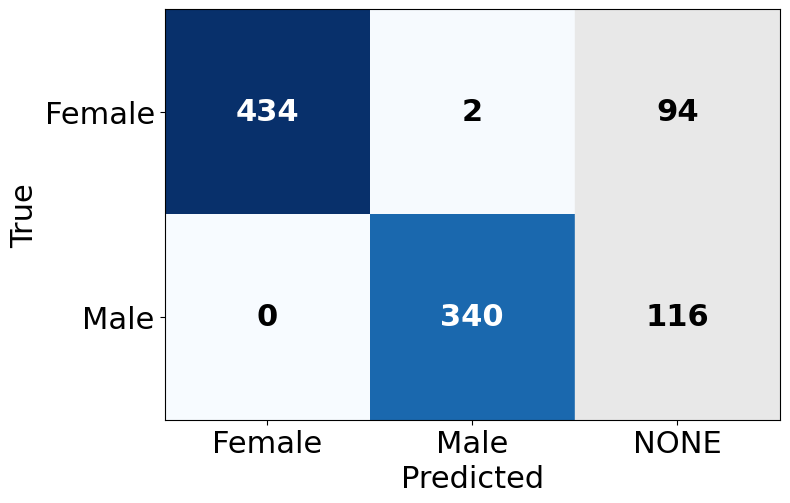

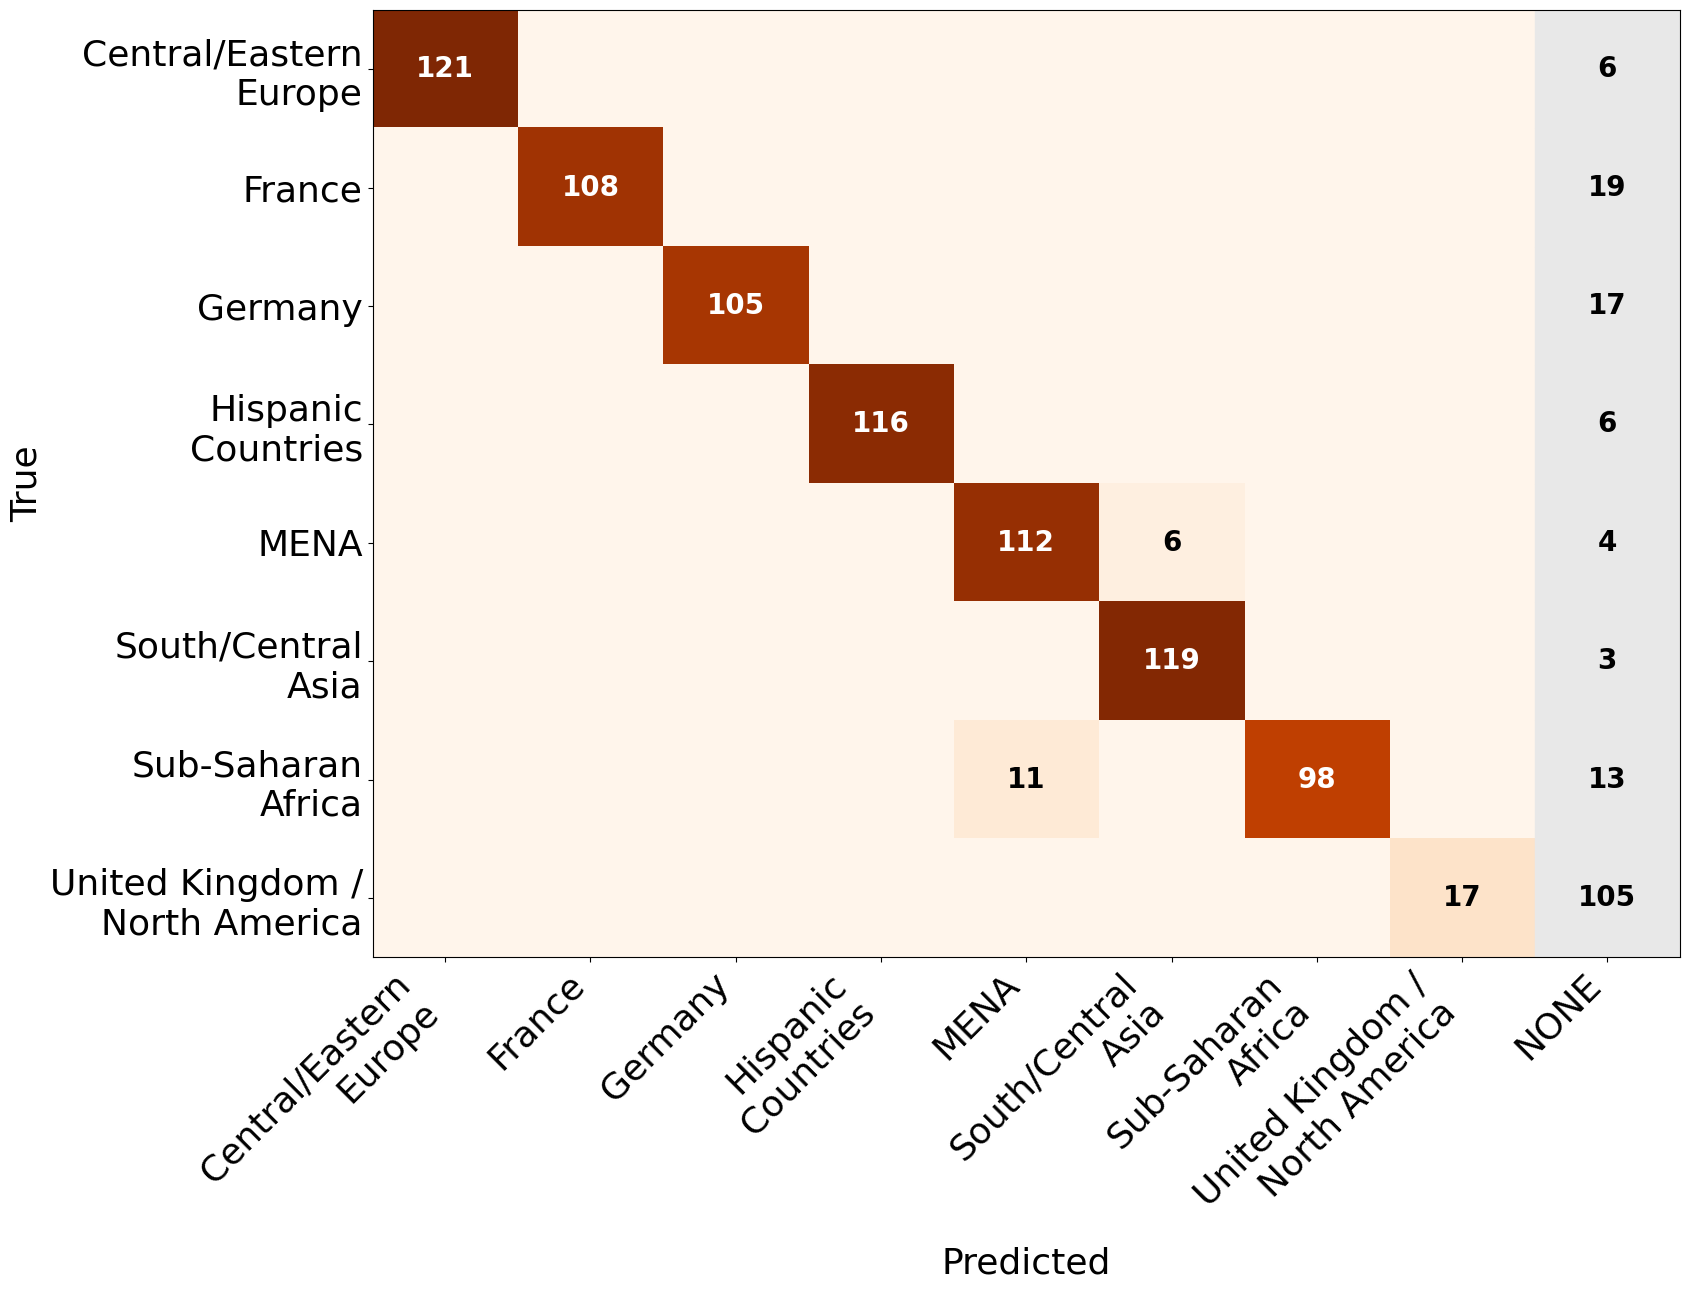

In [306]:
# --- Pooled confusion matrices WITH __NONE__ column ---
import textwrap
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT = _repo_root()
NONE_TOKEN = "__NONE__"

# Postprocessed stage-2 CSVs: per-axis refusals relabelled as __NONE__ by
# experiments/direct_probing/postprocess_none.ipynb.
POSTPROCESSED_DIR = REPO_ROOT / "experiments" / "direct_probing" / "results_direct_probing" / "stage2" / "postprocessed"
RUN_TAG = "direct_multimodel001"
EXTRA_RUNS = ["direct_complete002"]
EXTRA_CSV_TAGS = ["ministral3-8b", "e2b"]

CSV_PATHS = []
for tag in [RUN_TAG, *EXTRA_RUNS]:
    CSV_PATHS += sorted(POSTPROCESSED_DIR.glob(f"direct-probing-combined-{tag}*stage2.judgments.postprocessed.csv"))
for tag in EXTRA_CSV_TAGS:
    CSV_PATHS += sorted(POSTPROCESSED_DIR.glob(f"direct-probing-combined-{tag}-*stage2.judgments.postprocessed.csv"))
CSV_PATHS = list(dict.fromkeys(CSV_PATHS))


def _prepare(df_raw):
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    judge_aliases = sorted(df["judge_alias"].unique().tolist())
    df = df[df["judge_alias"] == judge_aliases[0]].reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if isinstance(s, str) and s.strip() else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_region"] = _meta.apply(lambda d: d.get("true_region"))
    df[["predicted_gender", "predicted_region"]] = df["final_class"].str.split(" - ", n=1, expand=True)
    df["predicted_gender"] = df["predicted_gender"].replace(NONE_TOKEN, pd.NA)
    df["predicted_region"] = df["predicted_region"].replace(NONE_TOKEN, pd.NA)
    df["gender_none"] = df["predicted_gender"].isna()
    df["region_none"] = df["predicted_region"].isna()
    df["gender_correct"] = (df["predicted_gender"] == df["true_gender"]).astype("boolean")
    df["gender_correct"] = df["gender_correct"].mask(df["gender_none"], pd.NA)
    df["region_correct"] = (df["predicted_region"] == df["true_region"]).astype("boolean")
    df["region_correct"] = df["region_correct"].mask(df["region_none"], pd.NA)
    df["both_correct"] = (df["gender_correct"] & df["region_correct"])
    return df


frames = []
for path in CSV_PATHS:
    raw = pd.read_csv(path)
    prepared = _prepare(raw)
    model = prepared["subject_model_alias"].iloc[0] if len(prepared) else path.stem
    prepared["model"] = model
    frames.append(prepared)

# Use dp_df to avoid collision with behavioral audit df
dp_df = pd.concat(frames, ignore_index=True)
ALL_REGIONS = sorted(dp_df["true_region"].dropna().unique().tolist())


def _wrap(label, width=14):
    if " / " in label:
        return " /\n".join(p.strip() for p in label.split(" / "))
    return "\n".join(textwrap.wrap(label, width=width, break_long_words=False))


FS_TICK = 22
FS_AXIS = 22
FS_CELL_G = 22
FS_TICK_R = 26
FS_AXIS_R = 26
FS_CELL_R = 20

# --- Gender with __NONE__ ---
gender_ct = pd.crosstab(dp_df["true_gender"], dp_df["predicted_gender"])
gender_none_per_true = dp_df.groupby("true_gender")["gender_none"].sum().astype(int)

rows_g = gender_ct.index.tolist()
cols_g = gender_ct.columns.tolist()
n_rows_g = len(rows_g)
n_cols_g = len(cols_g)

fig_gender, ax = plt.subplots(figsize=(8, 6))
ax.imshow(gender_ct.values.astype(float), cmap="Blues", aspect="equal",
          extent=[-0.5, n_cols_g - 0.5, n_rows_g - 0.5, -0.5])

for i in range(n_rows_g):
    ax.add_patch(plt.Rectangle((n_cols_g - 0.5, i - 0.5), 1, 1, color="#E8E8E8", zorder=0))

ax.set_xlim(-0.5, n_cols_g + 0.5)
ax.set_ylim(n_rows_g - 0.5, -0.5)
ax.set_xticks(range(n_cols_g + 1))
ax.set_yticks(range(n_rows_g))
ax.set_xticklabels(cols_g + ["NONE"], fontsize=FS_TICK)
ax.set_yticklabels(rows_g, fontsize=FS_TICK)
ax.set_xlabel("Predicted", fontsize=FS_AXIS)
ax.set_ylabel("True", fontsize=FS_AXIS)

_gmax = gender_ct.values.max()
for i, row in enumerate(rows_g):
    for j, col in enumerate(cols_g):
        v = gender_ct.values[i, j]
        tc = "white" if _gmax and v > 0.5 * _gmax else "black"
        ax.text(j, i, str(v), ha="center", va="center",
                fontsize=FS_CELL_G, fontweight="bold", color=tc)
    nv = int(gender_none_per_true.get(row, 0))
    ax.text(n_cols_g, i, str(nv), ha="center", va="center",
            fontsize=FS_CELL_G, fontweight="bold", color="black")

plt.tight_layout()
plt.show()

# --- Region with __NONE__ ---
region_ct = pd.crosstab(dp_df["true_region"], dp_df["predicted_region"]).reindex(
    index=ALL_REGIONS, columns=ALL_REGIONS, fill_value=0)
region_none_per_true = dp_df.groupby("true_region")["region_none"].sum().reindex(ALL_REGIONS, fill_value=0).astype(int)

n_rows_r = len(ALL_REGIONS)
n_cols_r = len(ALL_REGIONS)

fig_region, ax = plt.subplots(figsize=(17, 13))
ax.imshow(region_ct.values.astype(float), cmap="Oranges", aspect="auto",
          extent=[-0.5, n_cols_r - 0.5, n_rows_r - 0.5, -0.5])

for i in range(n_rows_r):
    ax.add_patch(plt.Rectangle((n_cols_r - 0.5, i - 0.5), 1, 1, color="#E8E8E8", zorder=0))

ax.set_xlim(-0.5, n_cols_r + 0.5)
ax.set_ylim(n_rows_r - 0.5, -0.5)
ax.set_xticks(range(n_cols_r + 1))
ax.set_yticks(range(n_rows_r))
ax.set_xticklabels([_wrap(c) for c in ALL_REGIONS] + ["NONE"],
                   rotation=45, ha="right", fontsize=FS_TICK_R)
ax.set_yticklabels([_wrap(r) for r in ALL_REGIONS], fontsize=FS_TICK_R)
ax.set_xlabel("Predicted", fontsize=FS_AXIS_R)
ax.set_ylabel("True", fontsize=FS_AXIS_R)

_rmax = region_ct.values.max()
for i, row in enumerate(ALL_REGIONS):
    for j in range(n_cols_r):
        v = region_ct.values[i, j]
        if v > 0:
            tc = "white" if _rmax and v > 0.5 * _rmax else "black"
            ax.text(j, i, str(v), ha="center", va="center",
                    fontsize=FS_CELL_R, fontweight="bold", color=tc)
    nv = int(region_none_per_true.get(row, 0))
    ax.text(n_cols_r, i, str(nv), ha="center", va="center",
            fontsize=FS_CELL_R, fontweight="bold", color="black")

plt.tight_layout()
plt.show()

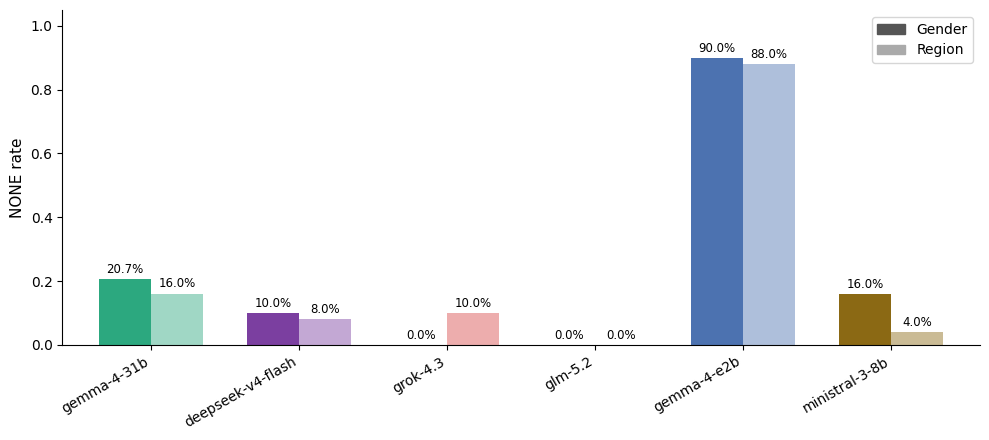

In [307]:
# --- NONE rate by model (gender vs. region) ---
# Per-axis __NONE__ rate = share of each model's rows where that axis carried no answer.
# Computed directly from dp_df (loaded in the confusion-matrix cell above).
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

ref = (
    dp_df.groupby("model")
         .agg(rows=("gender_none", "size"),
              gender_none=("gender_none", "sum"),
              region_none=("region_none", "sum"))
         .reset_index()
)
ref["gender_rate"] = ref["gender_none"] / ref["rows"]
ref["region_rate"] = ref["region_none"] / ref["rows"]

def _short(name):
    return name.replace("_paid", "").replace("_modal", "")

ref["label"] = ref["model"].apply(_short)

ORDER = ["gemma-4-31b_paid", "deepseek-v4-flash_paid", "grok-4.3_paid",
         "glm-5.2_paid", "gemma-4-e2b_modal", "ministral-3-8b_modal"]
ref = ref.set_index("model").reindex(ORDER).reset_index()

MODEL_COLORS_LIGHT = {k: plt.matplotlib.colors.to_rgba(v, alpha=0.45) for k, v in MODEL_COLORS.items()}

n = len(ref)
x = np.arange(n)
w = 0.35

fig_none, ax = plt.subplots(figsize=(10, 4.5))

for i, row in ref.iterrows():
    m = row["model"]
    ax.bar(x[i] - w / 2, row["gender_rate"], w, color=MODEL_COLORS[m])
    ax.bar(x[i] + w / 2, row["region_rate"], w, color=MODEL_COLORS_LIGHT[m])
    ax.text(x[i] - w / 2, row["gender_rate"] + 0.01, f"{row['gender_rate']:.1%}",
            ha="center", va="bottom", fontsize=8.5)
    ax.text(x[i] + w / 2, row["region_rate"] + 0.01, f"{row['region_rate']:.1%}",
            ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(ref["label"], rotation=30, ha="right", fontsize=10)
ax.set_ylabel("NONE rate", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.6, n - 0.4)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(handles=[Patch(color="#555555", label="Gender"),
                   Patch(color="#aaaaaa", label="Region")],
          loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

In [308]:
# --- Per-model accuracy + NONE + predicted-label distribution tables ---
# Two display DataFrames, both built from dp_df (loaded in the confusion-matrix cell above);
# they mirror the two LaTeX tables in experiments/direct_probing/eval_direct_probing.ipynb.
#   df_accuracy     : per-model gender/region/combined accuracy (NONE excluded from each
#                     rate) + usable-n behind each rate + per-axis NONE %.
#   df_distribution : per-model committed-prediction distribution (gender split + per-region
#                     counts) with the NONE counts.
from IPython.display import display

MODELS = [m for m in ["gemma-4-31b_paid", "deepseek-v4-flash_paid", "grok-4.3_paid",
                      "glm-5.2_paid", "gemma-4-e2b_modal", "ministral-3-8b_modal"]
          if m in dp_df["model"].unique()]
MODELS += [m for m in dp_df["model"].unique() if m not in MODELS]

ALL_REGIONS = sorted(dp_df["predicted_region"].dropna().unique().tolist())
_REGION_ABBR = {
    "Central/Eastern Europe": "C/E Eur", "France": "FR", "Germany": "DE",
    "Hispanic Countries": "Hisp", "MENA": "MENA", "South/Central Asia": "S/C Asia",
    "Sub-Saharan Africa": "SSA", "United Kingdom / North America": "UK/NA",
}


def _clean(name):
    return name.replace("_paid", "").replace("_modal", "")


def _pct(x):
    return f"{float(x) * 100:.1f}%"


# ---- accuracy rows (NONE axes auto-excluded via NA in the mean) ----
def _acc_row(d, label):
    return {
        "Model": label,
        "n": len(d),
        "Gender acc": d["gender_correct"].mean(),
        "Gender n": int(d["gender_correct"].notna().sum()),
        "Region acc": d["region_correct"].mean(),
        "Region n": int(d["region_correct"].notna().sum()),
        "Combined acc": d["both_correct"].mean(),
        "Combined n": int(d["both_correct"].notna().sum()),
    }


_acc_rows = [_acc_row(dp_df[dp_df["model"] == m], _clean(m)) for m in MODELS]
_acc_rows.append(_acc_row(dp_df, "All models"))
acc_table = pd.DataFrame(_acc_rows)
_models_part = acc_table.iloc[:-1].sort_values("Combined acc", ascending=False)
acc_table = pd.concat([_models_part, acc_table.iloc[[-1]]], ignore_index=True)


# ---- NONE counts + predicted-label distribution rows ----
def _dist_row(d, label):
    n = len(d)
    g_none = int(d["gender_none"].sum())
    r_none = int(d["region_none"].sum())
    pg = d.loc[~d["gender_none"], "predicted_gender"]
    pr = d.loc[~d["region_none"], "predicted_region"]
    gc = pg.value_counts()
    row = {
        "Model": label, "n": n,
        "Gender NONE": g_none, "Gender NONE %": g_none / n if n else float("nan"),
        "Region NONE": r_none, "Region NONE %": r_none / n if n else float("nan"),
        "Pred Male": int(gc.get("Male", 0)), "Pred Female": int(gc.get("Female", 0)),
    }
    rc = pr.value_counts()
    for reg in ALL_REGIONS:
        row[reg] = int(rc.get(reg, 0))
    return row


_dist_rows = [_dist_row(dp_df[dp_df["model"] == m], _clean(m)) for m in MODELS]
_dist_rows.append(_dist_row(dp_df, "All models"))
none_dist_table = pd.DataFrame(_dist_rows)
# align row order with acc_table (combined-accuracy sort, pooled row last)
_order = acc_table["Model"].tolist()
none_dist_table["_o"] = none_dist_table["Model"].map({m: i for i, m in enumerate(_order)})
none_dist_table = none_dist_table.sort_values("_o").drop(columns="_o").reset_index(drop=True)


# ===== df_accuracy: Model, n, Gender acc, n_g, Region acc, n_r, Combined acc, n_c, NONE % =====
df_accuracy = pd.DataFrame({
    "Model": acc_table["Model"],
    "n": acc_table["n"].astype(int),
    "Gender acc": acc_table["Gender acc"].map(_pct),
    "n_g": acc_table["Gender n"].astype(int),
    "Region acc": acc_table["Region acc"].map(_pct),
    "n_r": acc_table["Region n"].astype(int),
    "Combined acc": acc_table["Combined acc"].map(_pct),
    "n_c": acc_table["Combined n"].astype(int),
    "Gender NONE %": none_dist_table["Gender NONE %"].map(_pct),
    "Region NONE %": none_dist_table["Region NONE %"].map(_pct),
})

# ===== df_distribution: Model, Male, Female, Gender NONE, <8 region abbrevs>, Region NONE =====
df_distribution = pd.DataFrame({
    "Model": none_dist_table["Model"],
    "Male": none_dist_table["Pred Male"].astype(int),
    "Female": none_dist_table["Pred Female"].astype(int),
    "Gender NONE": none_dist_table["Gender NONE"].astype(int),
})
for reg in ALL_REGIONS:
    df_distribution[_REGION_ABBR[reg]] = none_dist_table[reg].astype(int)
df_distribution["Region NONE"] = none_dist_table["Region NONE"].astype(int)

print("df_accuracy:")
display(df_accuracy)
print("\ndf_distribution:")
display(df_distribution)

df_accuracy:


,Model,n,Gender acc,n_g,Region acc,n_r,Combined acc,n_c,Gender NONE %,Region NONE %
0,deepseek-v4-flash,50,100.0%,45,100.0%,46,100.0%,45,10.0%,8.0%
1,grok-4.3,50,100.0%,50,100.0%,45,100.0%,45,0.0%,10.0%
2,glm-5.2,50,100.0%,50,100.0%,50,100.0%,50,0.0%,0.0%
3,gemma-4-e2b,50,100.0%,5,100.0%,6,100.0%,5,90.0%,88.0%
4,gemma-4-31b,736,99.8%,584,97.6%,618,97.2%,577,20.7%,16.0%
5,ministral-3-8b,50,97.6%,42,95.8%,48,92.9%,42,16.0%,4.0%
6,All models,986,99.7%,776,97.9%,813,97.5%,764,21.3%,17.5%



df_distribution:


,Model,Male,Female,Gender NONE,C/E Eur,FR,DE,Hisp,MENA,S/C Asia,SSA,UK/NA,Region NONE
0,deepseek-v4-flash,21,24,5,7,7,5,6,6,6,5,4,4
1,grok-4.3,24,26,0,7,7,6,6,6,6,6,1,5
2,glm-5.2,24,26,0,7,7,6,6,6,6,6,6,0
3,gemma-4-e2b,4,1,45,1,0,0,0,2,3,0,0,44
4,gemma-4-31b,248,336,152,92,80,82,92,95,98,78,1,118
5,ministral-3-8b,21,21,8,7,7,6,6,8,6,3,5,2
6,All models,342,434,210,121,108,105,116,123,125,98,17,173


## Internal Probing

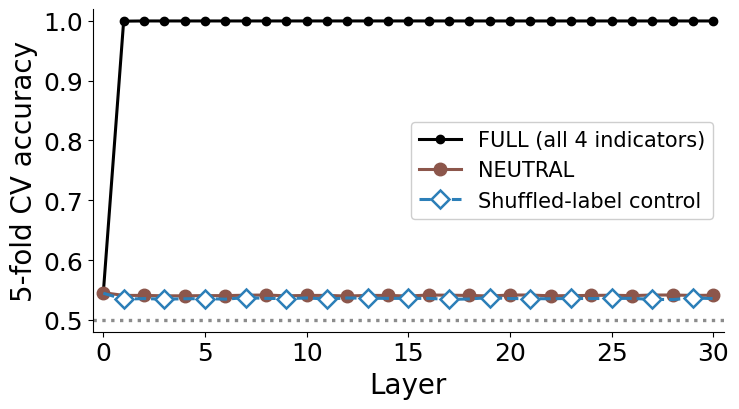

In [309]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


CKPT_DIR = (
    _repo_root()
    / "internal_representation_personas"
    / "results_modal_gemma4_31b_sweep_v4"
    / "sweep"
    / "checkpoints"
)

full    = json.loads((CKPT_DIR / "FULL.json").read_text())
neutral = json.loads((CKPT_DIR / "NEUTRAL_USER_ONLY.json").read_text())

layers = np.asarray(full["layers"])
MAX_LAYER = 30
_m = layers <= MAX_LAYER
_L = layers[_m]
_neu  = np.asarray(neutral["cv_mean"])[_m]
_ctrl = np.asarray(neutral["control_cv_mean"])[_m]

# NEUTRAL markers on even layers, control diamonds on odd layers — interleaved
even_idx = list(np.where(_L % 2 == 0)[0])
odd_idx  = list(np.where(_L % 2 == 1)[0])

FS = 20
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# FULL — black, marker at every layer
ax.plot(_L, np.asarray(full["cv_mean"])[_m], color="#000000", ls="-", lw=2.2,
        marker="o", markersize=6, label="FULL (all 4 indicators)")

# NEUTRAL — brown, continuous line, markers on even layers only
ax.plot(_L, _neu, color="#8c564b", ls="-", lw=2.2,
        marker="o", markersize=9, markevery=even_idx, label="NEUTRAL")

# Shuffled-label control — blue hollow diamonds, continuous line, markers on odd layers only
ax.plot(_L, _ctrl, color="#2c7fb8", ls="--", lw=2.2,
        marker="D", markersize=9, markevery=odd_idx,
        markerfacecolor="white", markeredgecolor="#2c7fb8", markeredgewidth=1.8,
        label="Shuffled-label control", zorder=2)

ax.axhline(0.5, color="grey", lw=2.4, ls=":", alpha=0.9, zorder=1)

ax.set_ylim(0.48, 1.02)
ax.set_xlim(_L.min() - 0.5, _L.max() + 0.5)
ax.set_xlabel("Layer", fontsize=FS)
ax.set_ylabel("5-fold CV accuracy", fontsize=FS)
ax.tick_params(labelsize=FS - 2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center right", fontsize=FS - 5, framealpha=0.95)

fig.tight_layout()
plt.show()


## Behavioral Audit - General results

In [310]:
# --- Behavioral-audit loader: baseline + full (persona) stage-2 judgments ---
# Self-contained (the significance-table cells below use `combined_df` instead, but the
# distribution / NONE-rate / baseline-vs-persona / vector figures need the raw stage-2
# rows). Resolves each run from logs/ first, then results_behavioral_audit/results_<tag>/.
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


BA_REPO_ROOT = _repo_root()
BA_LOGS_DIR = BA_REPO_ROOT / "logs" / "judges" / "behavioral-audit"
BA_RESULTS_DIR = BA_REPO_ROOT / "experiments" / "behavioral_audit" / "results_behavioral_audit"
BA_HIER = BA_REPO_ROOT / "experiments" / "behavioral_audit" / "indicator_hierarchy"

BASELINE_RUNS = ["baseline002", "baseline003", "baseline-e2b", "baseline-ministral3-8b"]
FULL_RUNS = ["full001", "full002", "full001-e2b", "full001-ministral3-8b"]
BASELINE_MODELS = [
    "gemma-4-31b_paid", "deepseek-v4-flash_paid", "grok-4.3_paid",
    "glm-5.2_paid", "gemma-4-e2b_modal", "ministral-3-8b_modal",
]
MODEL_LABELS = {m: m.replace("_paid", "").replace("_modal", "") for m in BASELINE_MODELS}

# shared colours for the baseline-vs-persona / vector / distribution figures
BASE_C, MALE_C, FEMALE_C = "#666666", "#4C72B0", "#E97070"
GENDER_COLORS = {"Male": "#5B9BD5", "Female": "#E07B54"}
_UNSPEC_COLOR = "#B0B0B0"

with open(BA_HIER / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(BA_HIER / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_CLASSES = [smg["name"] for mg in _jobs_data["job_classification"]["major_groups"]
              for smg in mg["sub_major_groups"]]
Q1_MAJOR_GROUPS = {smg["name"]: mg["name"] for mg in _jobs_data["job_classification"]["major_groups"]
                   for smg in mg["sub_major_groups"]}
Q2_CLASSES = [nf["name"] for bf in _college_data["college_major_classification"]["broad_fields"]
              for nf in bf["narrow_fields"]]
Q2_BROAD_FIELDS = {nf["name"]: bf["name"] for bf in _college_data["college_major_classification"]["broad_fields"]
                   for nf in bf["narrow_fields"]}
levels_q1 = list(dict.fromkeys(Q1_MAJOR_GROUPS.values()))   # 10 major groups
levels_q2 = list(dict.fromkeys(Q2_BROAD_FIELDS.values()))   # 11 broad fields


def _resolve_stage2_csv(run_tag, q_tag):
    fname = f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv"
    in_logs = BA_LOGS_DIR / fname
    if in_logs.exists():
        return in_logs
    in_results = BA_RESULTS_DIR / f"results_{run_tag}" / fname
    if in_results.exists():
        return in_results
    raise FileNotFoundError(f"stage-2 CSV not found for {run_tag} {q_tag}: {in_logs} / {in_results}")


def _load_ba(run_tags, q_tag, group_col):
    frames = []
    for run_tag in run_tags:
        df_raw = pd.read_csv(_resolve_stage2_csv(run_tag, q_tag))
        df = df_raw[df_raw["status"] == "success"].copy()
        _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
        df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
        df["true_race"] = _meta.apply(lambda d: d.get("true_race"))
        df["run"] = run_tag
        df[group_col] = df["final_class"].map(
            Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


df_b_q1 = _load_ba(BASELINE_RUNS, "q1", "major_group")
df_b_q2 = _load_ba(BASELINE_RUNS, "q2", "broad_field")
df_f_q1 = _load_ba(FULL_RUNS, "q1", "major_group")
df_f_q2 = _load_ba(FULL_RUNS, "q2", "broad_field")

print("Behavioral-audit data loaded:")
for nm, d in [("baseline Q1", df_b_q1), ("baseline Q2", df_b_q2),
              ("full Q1", df_f_q1), ("full Q2", df_f_q2)]:
    print(f"  {nm:12s}: {len(d):5d} rows, {d['subject_model_alias'].nunique()} models")

Behavioral-audit data loaded:
  baseline Q1 :   300 rows, 6 models
  baseline Q2 :   300 rows, 6 models
  full Q1     : 23141 rows, 6 models
  full Q2     : 23211 rows, 6 models


### Persona cohort composition

Distribution of the synthetic persona population over the gender and region dimensions
(deduplicated by `history_id` from the full-run stage-2 metadata).

Unique personas: 3869


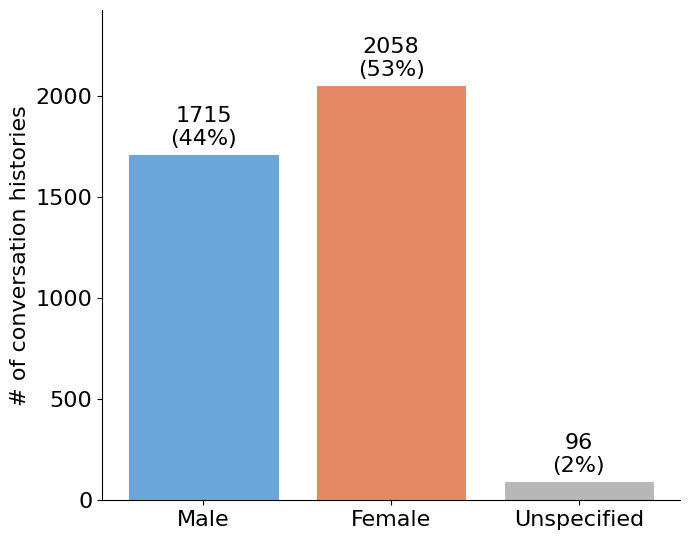

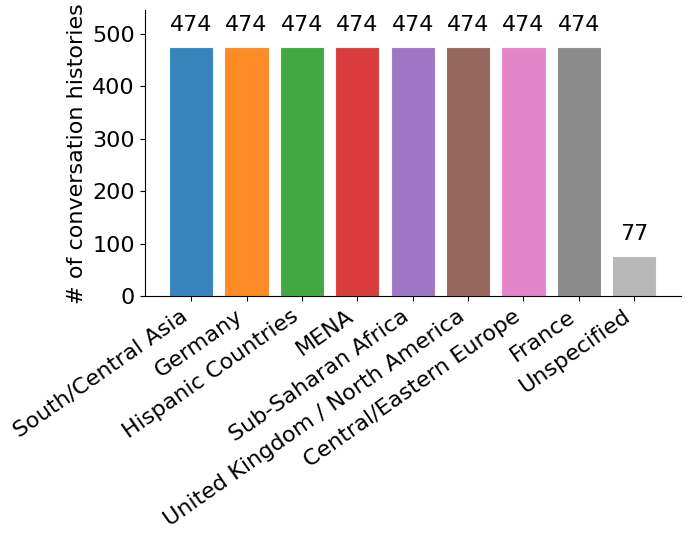

In [311]:
# --- Persona cohort: gender + region distribution (gender_distribution / region_distribution) ---
# Dedupe personas by history_id so counts reflect the population, not population × models.
_meta_all = df_f_q1[["true_gender", "true_race"]].copy()
_meta_all["history_id"] = df_f_q1["metadata"].apply(
    lambda s: json.loads(s).get("history_id") if pd.notna(s) and s else None)
personas = _meta_all.dropna(subset=["history_id"]).drop_duplicates("history_id")
_n = len(personas)
print(f"Unique personas: {_n}")

_gender_ser = (personas["true_gender"].fillna("Unspecified").value_counts()
               .reindex([g for g in ["Male", "Female", "Unspecified"]
                         if g in personas["true_gender"].fillna("Unspecified").unique()]))
_region_ser = personas["true_race"].fillna("Unspecified").value_counts().sort_values(ascending=False)

_LS = 16

# gender_distribution
fig, ax = plt.subplots(figsize=(7, 5.5))
colors = [GENDER_COLORS.get(g, _UNSPEC_COLOR) for g in _gender_ser.index]
bars = ax.bar(_gender_ser.index, _gender_ser.values, color=colors, alpha=0.9,
              edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, _gender_ser.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + _n * 0.006,
            f"{v}\n({v / _n:.0%})", ha="center", va="bottom", fontsize=_LS)
ax.set_ylabel("# of conversation histories", fontsize=_LS)
ax.set_ylim(0, _gender_ser.max() * 1.18)
ax.tick_params(axis="both", labelsize=_LS)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.show()

# region_distribution
fig, ax = plt.subplots(figsize=(7, 5.5))
r_cmap = plt.cm.tab10
colors = [r_cmap(i % 10) if k != "Unspecified" else _UNSPEC_COLOR
          for i, k in enumerate(_region_ser.index)]
bars = ax.bar(range(len(_region_ser)), _region_ser.values, color=colors, alpha=0.9,
              edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, _region_ser.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + _n * 0.006,
            f"{v}", ha="center", va="bottom", fontsize=_LS)
ax.set_xticks(range(len(_region_ser)))
ax.set_xticklabels(_region_ser.index, rotation=35, ha="right", fontsize=_LS)
ax.set_ylabel("# of conversation histories", fontsize=_LS)
ax.set_ylim(0, _region_ser.max() * 1.15)
ax.tick_params(axis="y", labelsize=_LS)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.show()

### None-value rate per model (persona runs)

Share of each model's responses the judge could not classify (`none_declared`), over the
persona/full runs — Q1 (jobs) and Q2 (college).

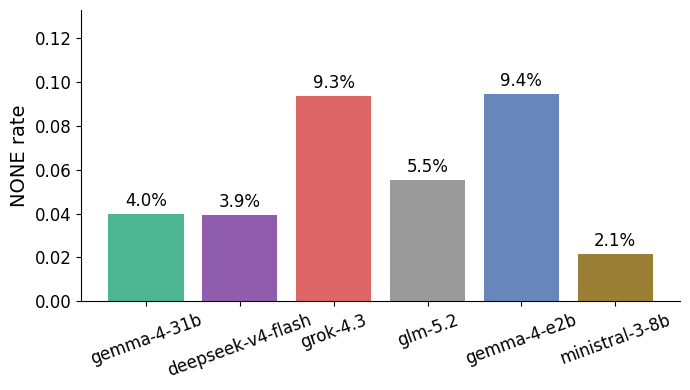

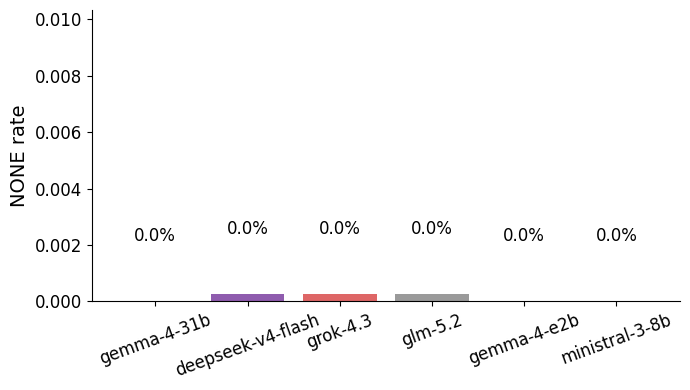

In [312]:
# --- none_rate_per_model (persona/full), Q1 + Q2 ---
def _none_rate_fig(df_raw_all, label):
    df_raw_all = df_raw_all.copy()
    df_raw_all["is_none"] = df_raw_all["none_declared"].astype(str).str.lower() == "true"
    models = [m for m in BASELINE_MODELS if m in df_raw_all["subject_model_alias"].unique()]
    rates = [df_raw_all[df_raw_all["subject_model_alias"] == m]["is_none"].mean() for m in models]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar([MODEL_LABELS[m] for m in models], rates,
                  color=[MODEL_COLORS.get(m, "#888888") for m in models], alpha=0.85)
    for bar, r in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{r:.1%}", ha="center", va="bottom", fontsize=12)
    ax.set_ylabel("NONE rate", fontsize=14)
    ax.set_ylim(0, max(rates) * 1.3 + 0.01 if any(rates) else 0.05)
    ax.tick_params(axis="x", rotation=20, labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    plt.tight_layout()
    plt.show()

_none_rate_fig(df_f_q1, "Q1")   # none_rate_per_model_q1
_none_rate_fig(df_f_q2, "Q2")   # none_rate_per_model_q2

### Baseline

Persona-free baseline runs: the model answers the same question with no persona context.
The dumbbell figures compare, per model and per category, the **baseline** proportion
(open dot) against the **persona** proportion (filled dot); the none-value rates below are
the baseline analogue of the persona none-rates above.

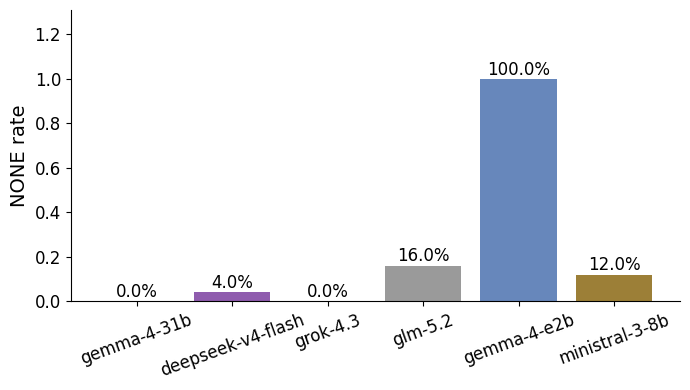

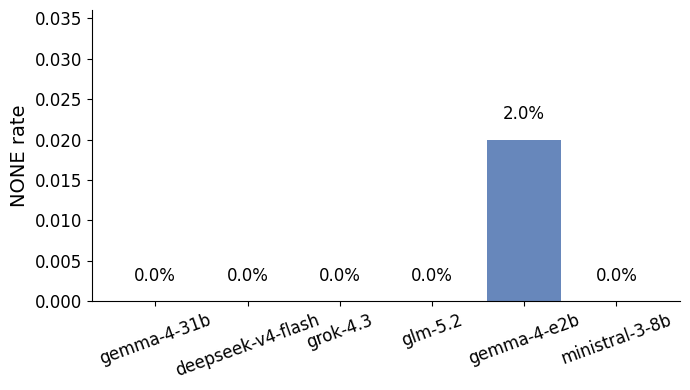

In [313]:
# --- baseline_none_rate_per_model, Q1 + Q2 (baseline runs) ---
_none_rate_fig(df_b_q1, "Q1")   # baseline_none_rate_per_model_q1
_none_rate_fig(df_b_q2, "Q2")   # baseline_none_rate_per_model_q2

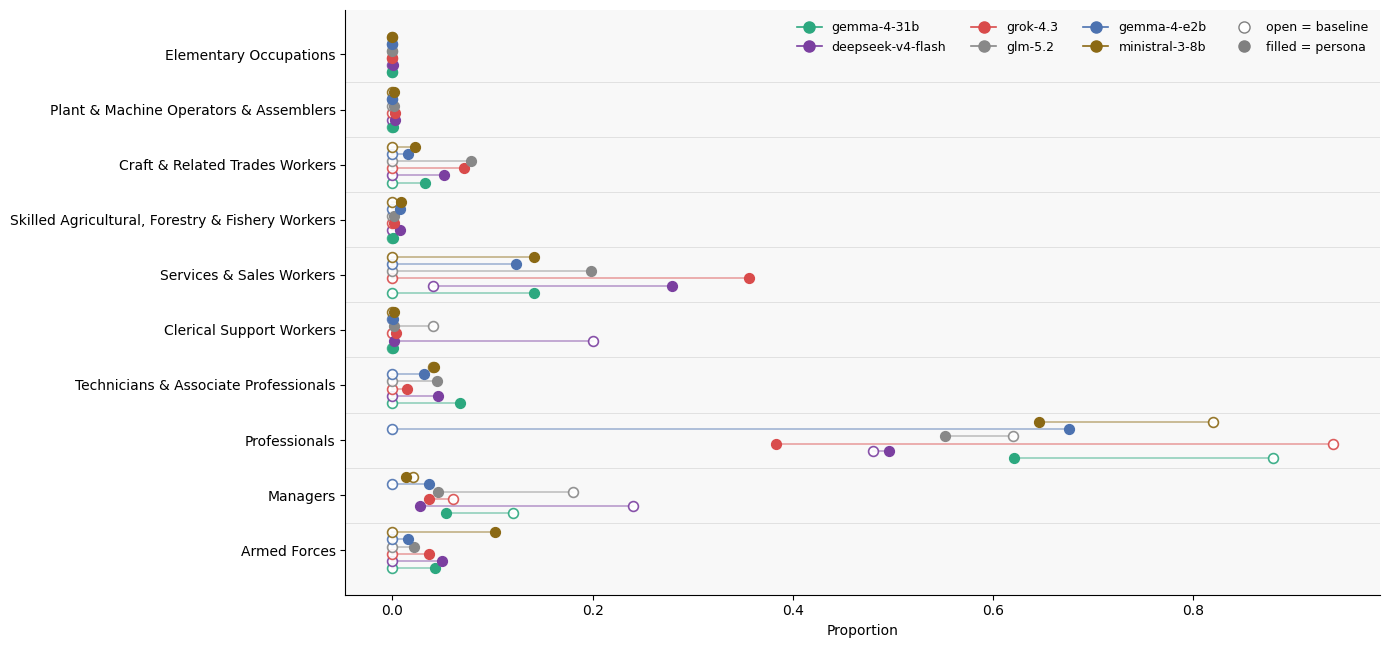

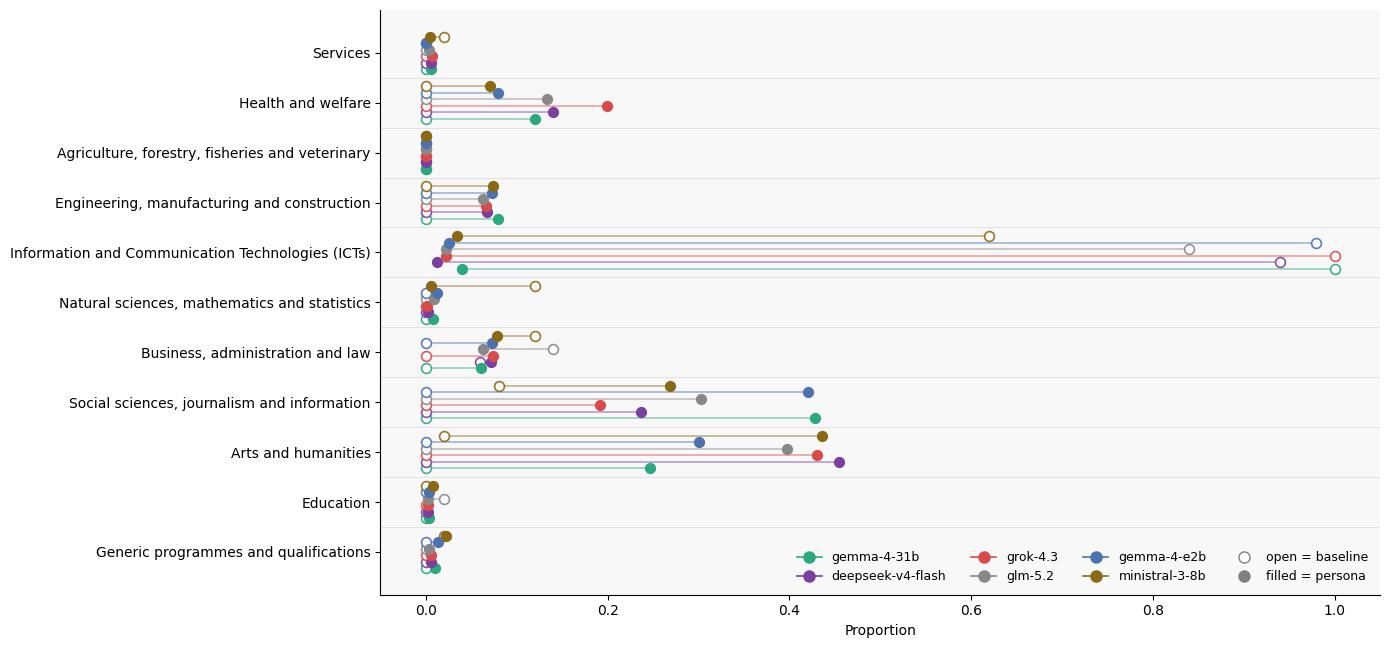

In [314]:
# --- baseline_vs_persona_all_models (Q1 + Q2) — dumbbell: baseline → persona per model ---
# Open dot = baseline proportion, filled dot = persona proportion, one pair per model,
# for each recommendation category. Proportions are over the collapsed group column.
from matplotlib.lines import Line2D

_SPREAD = 0.13


def _plot_all_models_single_q(df_b, df_f, levels, group_col, legend_loc="lower right"):
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_facecolor("#F8F8F8")
    n_cat = len(levels)
    n_models = len(BASELINE_MODELS)

    for ci, lvl in enumerate(levels):
        for mi, model in enumerate(BASELINE_MODELS):
            offset = (mi - (n_models - 1) / 2) * _SPREAD
            y = ci + offset
            col = MODEL_COLORS.get(model, "#888888")
            gb = df_b[df_b["subject_model_alias"] == model]
            gf = df_f[df_f["subject_model_alias"] == model]
            pb = (gb[group_col] == lvl).mean() if len(gb) else 0.0
            pf = (gf[group_col] == lvl).mean() if len(gf) else 0.0
            ax.plot([pb, pf], [y, y], color=col, lw=1.2, alpha=0.5, zorder=3)
            ax.scatter(pb, y, color="white", edgecolors=col, s=50, lw=1.2, zorder=4, alpha=0.9)
            ax.scatter(pf, y, color=col, s=50, zorder=5)

    for ci in range(n_cat - 1):
        ax.axhline(ci + 0.5, color="#dddddd", lw=0.6, zorder=1)

    ax.set_yticks(range(n_cat))
    ax.set_yticklabels(levels, fontsize=10)
    ax.set_xlabel("Proportion", fontsize=10)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

    leg = [Line2D([0], [0], marker="o", color=MODEL_COLORS.get(m, "#888888"), lw=1.2,
                  markerfacecolor=MODEL_COLORS.get(m, "#888888"), markersize=8,
                  label=MODEL_LABELS[m]) for m in BASELINE_MODELS]
    leg += [
        Line2D([0], [0], marker="o", color="grey", lw=0, markerfacecolor="white",
               markeredgecolor="grey", markersize=8, label="open = baseline"),
        Line2D([0], [0], marker="o", color="grey", lw=0, markerfacecolor="grey",
               markersize=8, label="filled = persona"),
    ]
    ax.legend(handles=leg, fontsize=9, loc=legend_loc, ncol=4, frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

# baseline_vs_persona_all_models_q1
_plot_all_models_single_q(df_b_q1, df_f_q1, levels_q1, "major_group", legend_loc="upper right")
# baseline_vs_persona_all_models_q2  (paper's "baseline_q2" dumbbell)
_plot_all_models_single_q(df_b_q2, df_f_q2, levels_q2, "broad_field")

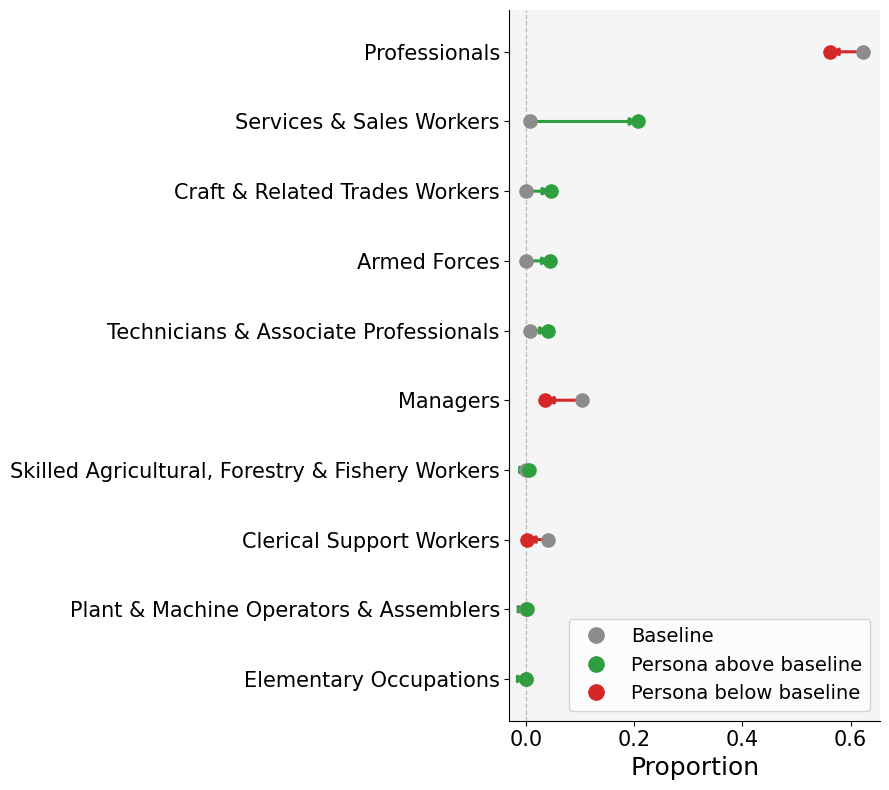

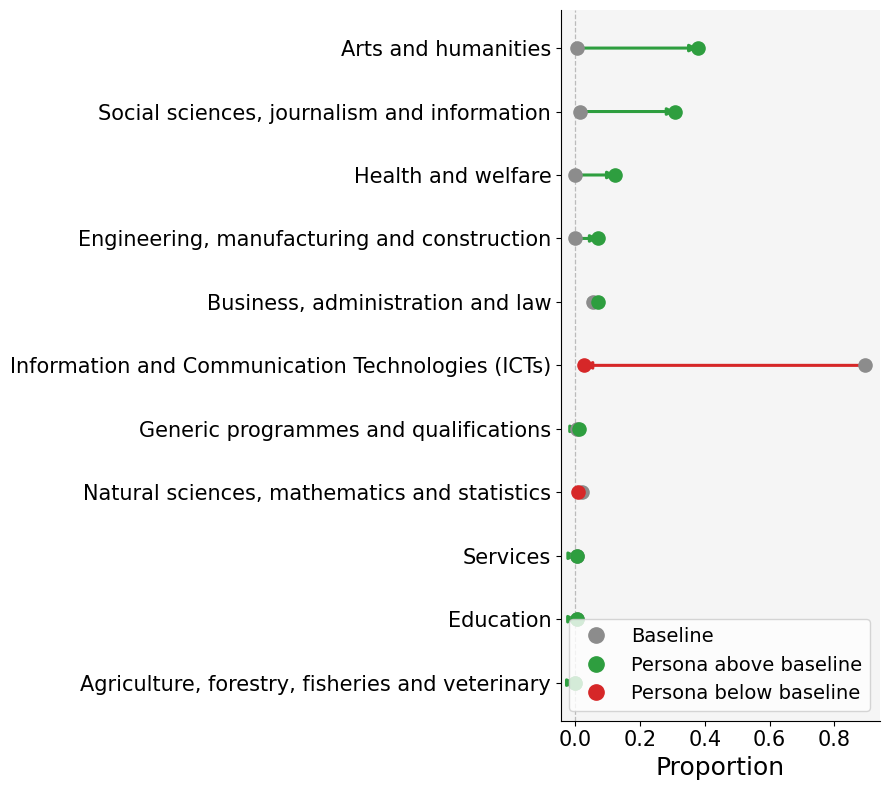

In [315]:
# --- baseline_q1 / baseline_q2 — merged-models lollipop: baseline -> persona ---
# Single dot per category for the baseline (grey) and a lollipop to the persona
# proportion, coloured GREEN when persona > baseline and RED when persona < baseline.
# Proportions are merged over models = mean of each model's per-category proportion
# (equal weight per model), matching the notebook's merged-vector convention.
from matplotlib.lines import Line2D


def _merged_proportion(df, group_col, levels, models=BASELINE_MODELS):
    """Mean over contributing models of that model's share in each category."""
    parts = []
    for m in models:
        sub = df[df["subject_model_alias"] == m]
        if len(sub) == 0:
            continue
        parts.append([(sub[group_col] == lvl).mean() for lvl in levels])
    return np.mean(parts, axis=0) if parts else np.zeros(len(levels))


def _plot_baseline_lollipop(df_b, df_f, levels, group_col, order="persona"):
    base = _merged_proportion(df_b, group_col, levels)
    pers = _merged_proportion(df_f, group_col, levels)

    idx = list(range(len(levels)))
    if order == "persona":              # largest persona proportion on top
        idx = sorted(idx, key=lambda i: pers[i])
    lv = [levels[i] for i in idx]
    b = [base[i] for i in idx]
    p = [pers[i] for i in idx]

    UP_C, DOWN_C, BASE_DOT = "#2E9E3F", "#D62728", "#8C8C8C"

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.set_facecolor("#F5F5F5")
    for yi, (pb, pf) in enumerate(zip(b, p)):
        col = UP_C if pf >= pb else DOWN_C
        ax.annotate("", xy=(pf, yi), xytext=(pb, yi),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.2,
                                    shrinkA=0, shrinkB=0))
        ax.scatter(pb, yi, color=BASE_DOT, s=90, zorder=4)
        ax.scatter(pf, yi, color=col, s=90, zorder=5)

    ax.axvline(0, color="#bbbbbb", ls="--", lw=0.9, zorder=1)
    ax.set_yticks(range(len(lv)))
    ax.set_yticklabels(lv, fontsize=15)
    ax.set_xlabel("Proportion", fontsize=18)
    ax.tick_params(axis="x", labelsize=15)
    ax.set_ylim(-0.6, len(lv) - 0.4)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

    leg = [
        Line2D([0], [0], marker="o", lw=0, markerfacecolor=BASE_DOT,
               markeredgecolor=BASE_DOT, markersize=11, label="Baseline"),
        Line2D([0], [0], marker="o", lw=0, markerfacecolor=UP_C,
               markeredgecolor=UP_C, markersize=11, label="Persona above baseline"),
        Line2D([0], [0], marker="o", lw=0, markerfacecolor=DOWN_C,
               markeredgecolor=DOWN_C, markersize=11, label="Persona below baseline"),
    ]
    ax.legend(handles=leg, fontsize=14, loc="lower right", frameon=True)
    plt.tight_layout()
    plt.show()


# baseline_q1  (jobs — the missing Q1 companion to the paper's baseline_q2)
_plot_baseline_lollipop(df_b_q1, df_f_q1, levels_q1, "major_group")
# baseline_q2  (college — reproduces the paper's baseline_q2.png)
_plot_baseline_lollipop(df_b_q2, df_f_q2, levels_q2, "broad_field")


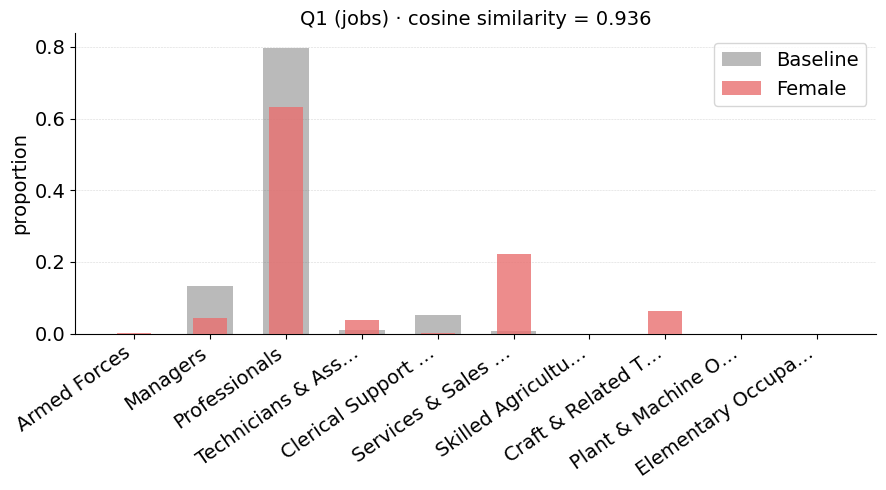

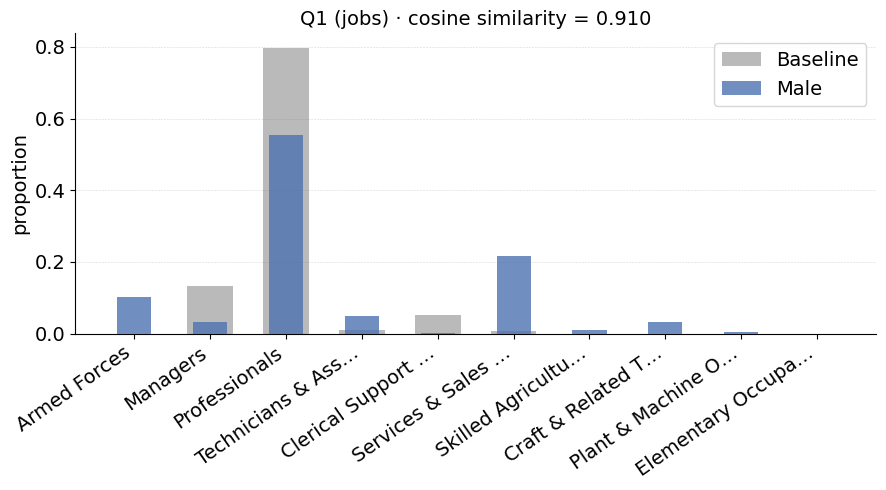

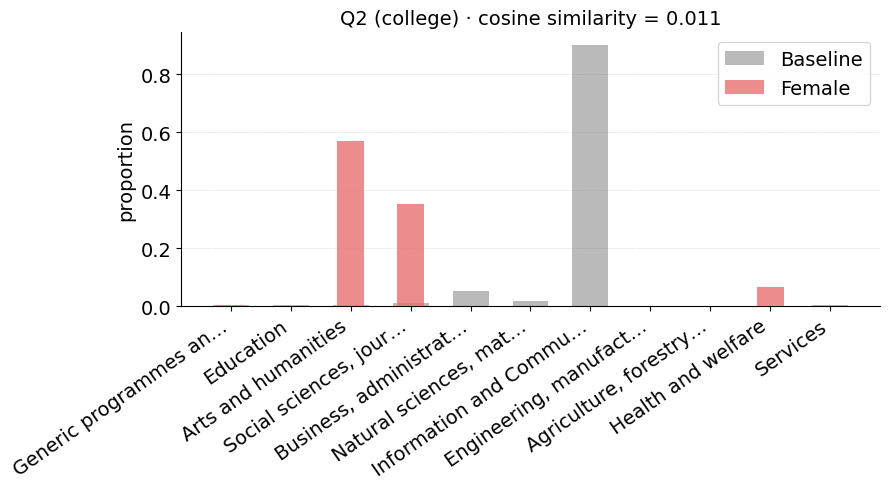

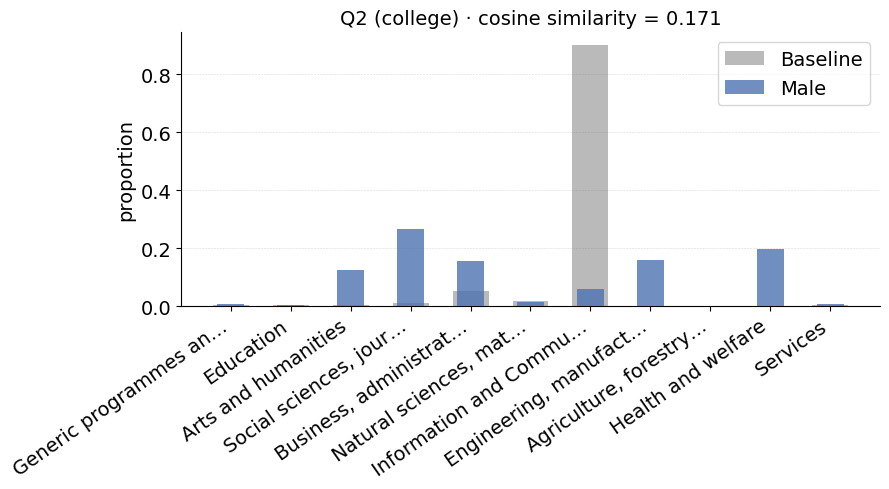

In [316]:
# --- baseline_vector_{female,male}_{q1,q2}: merged baseline vs gender proportion vectors ---
# Each vector = mean over contributing models of that model's normalised class distribution
# (equal weight per model). Overlay baseline (grey) with the gender vector; title = cosine.
def _prob_vec(df, group_col, levels):
    if len(df) == 0:
        return np.zeros(len(levels))
    vc = df[group_col].value_counts(normalize=True)
    return vc.reindex(levels, fill_value=0.0).values


def _merged_prob_vec(df, group_col, levels, models=BASELINE_MODELS):
    parts = []
    for m in models:
        sub = df[df["subject_model_alias"] == m]
        if len(sub) == 0:
            continue
        v = _prob_vec(sub, group_col, levels)
        if v.sum() <= 1e-9:
            continue
        parts.append(v)
    return np.mean(parts, axis=0) if parts else np.zeros(len(levels))


def _cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0


def _vector_overlay(df_b, df_f, group_col, levels, q_label, label_max):
    v_base = _merged_prob_vec(df_b, group_col, levels)
    fem = df_f[df_f["true_gender"].astype(str).str.lower() == "female"]
    mal = df_f[df_f["true_gender"].astype(str).str.lower() == "male"]
    v_female = _merged_prob_vec(fem, group_col, levels)
    v_male = _merged_prob_vec(mal, group_col, levels)
    labels = [l if len(l) <= label_max else l[:label_max - 1] + "…" for l in levels]
    xi = np.arange(len(levels))

    for v_top, top_c, top_lbl in [(v_female, FEMALE_C, "Female"), (v_male, MALE_C, "Male")]:
        cos_val = _cosine(v_base, v_top)
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.bar(xi, v_base, width=0.6, color=BASE_C, alpha=0.45, label="Baseline", zorder=2)
        ax.bar(xi, v_top, width=0.45, color=top_c, alpha=0.80, label=top_lbl, zorder=3)
        ax.set_xticks(xi)
        ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=14)
        ax.set_ylabel("proportion", fontsize=14)
        ax.tick_params(axis="y", labelsize=14)
        ax.set_title(f"{q_label} · cosine similarity = {cos_val:.3f}", fontsize=14)
        ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        ax.legend(fontsize=14, loc="upper right")
        plt.tight_layout()
        plt.show()

# Q1: baseline_vector_female_q1 / baseline_vector_male_q1
_vector_overlay(df_b_q1, df_f_q1, "major_group", levels_q1, "Q1 (jobs)", 18)
# Q2: baseline_vector_female_q2 / baseline_vector_male_q2
_vector_overlay(df_b_q2, df_f_q2, "broad_field", levels_q2, "Q2 (college)", 22)

### Region proportion vectors vs. baseline

Grouped bar chart per recommendation category: one bar per region (merged over models,
equal model weight) with the persona-free **baseline** proportion drawn as a black tick
per category. Q1 (jobs) and Q2 (college).

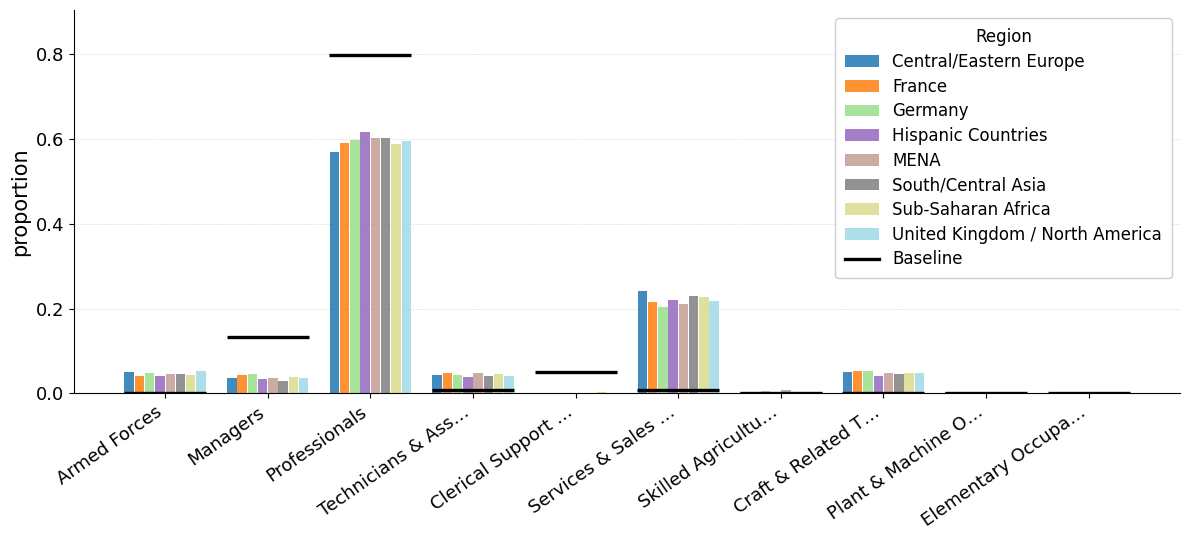

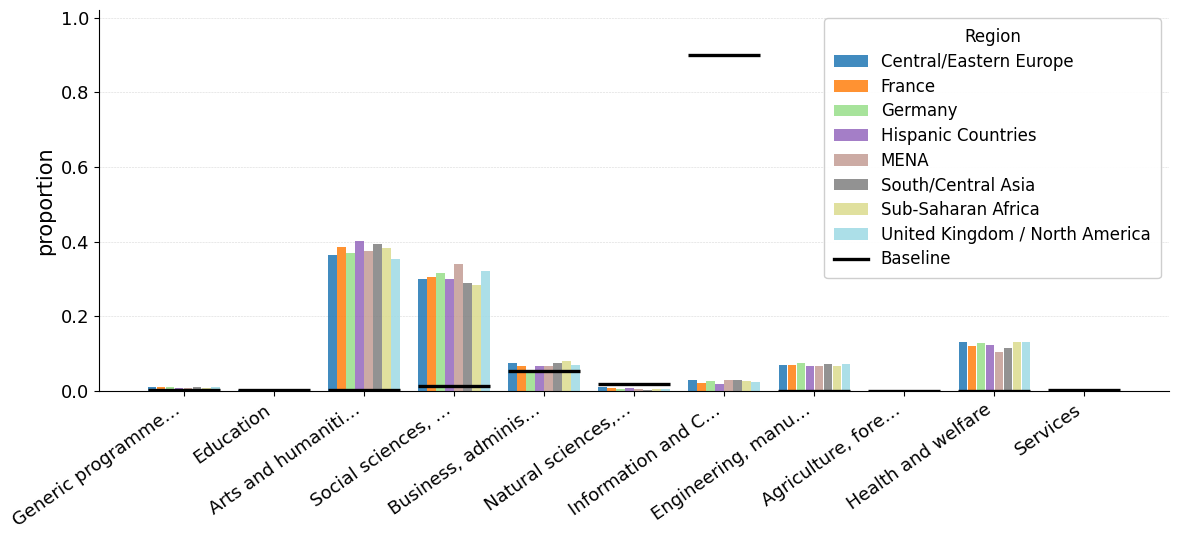

In [317]:
# --- q{1,2}_region_grouped_bars: per-region proportion vectors + baseline tick ---
# One bar per region per category (merged over models = mean of per-model normalised
# proportion vectors, equal model weight), black tick = persona-free baseline. Legend
# inside the axes. Reuses _merged_prob_vec from the vector-overlay cell above.
from matplotlib.lines import Line2D as _L2D

REGION_CMAP = plt.cm.tab20


def _region_vectors(df_f, group_col, levels):
    """region -> merged (equal model weight) proportion vector over `levels`."""
    regions = sorted(df_f["true_race"].dropna().unique())
    return {reg: _merged_prob_vec(df_f[df_f["true_race"] == reg], group_col, levels)
            for reg in regions}


_FS_TICK, _FS_AXIS, _FS_LEGEND = 13, 15, 12

for q_label, df_b, df_f, group_col, levels in [
    ("Q1", df_b_q1, df_f_q1, "major_group", levels_q1),
    ("Q2", df_b_q2, df_f_q2, "broad_field", levels_q2),
]:
    vecs   = _region_vectors(df_f, group_col, levels)
    v_base = _merged_prob_vec(df_b, group_col, levels)
    regions = list(vecs.keys())
    n_reg, n_lev = len(regions), len(levels)
    mat = np.array([vecs[r] for r in regions])            # (n_reg, n_lev)
    short_lvls = [l if len(l) <= 18 else l[:17] + "…" for l in levels]

    bar_w = 0.8 / n_reg
    half  = 0.4
    xi    = np.arange(n_lev)

    fig, ax = plt.subplots(figsize=(max(12, n_lev * 1.05), 5.5))

    for ri, reg in enumerate(regions):
        offset = (ri - n_reg / 2 + 0.5) * bar_w
        ax.bar(xi + offset, mat[ri], width=bar_w * 0.92,
               color=REGION_CMAP(ri / max(n_reg - 1, 1)), alpha=0.85,
               label=reg, zorder=2)

    # baseline: short horizontal tick spanning each category group
    for i_lev, b_val in enumerate(v_base):
        ax.plot([xi[i_lev] - half, xi[i_lev] + half], [b_val, b_val],
                color="black", linewidth=2.4, solid_capstyle="butt", zorder=6)

    region_handles, region_labels = ax.get_legend_handles_labels()
    baseline_handle = _L2D([0], [0], color="black", lw=2.4, label="Baseline")
    ax.set_ylim(top=ax.get_ylim()[1] * 1.08)              # headroom for in-axes legend
    ax.legend(handles=region_handles + [baseline_handle],
              labels=region_labels + ["Baseline"],
              fontsize=_FS_LEGEND, loc="upper right",
              frameon=True, framealpha=0.95, borderpad=0.6, labelspacing=0.4,
              title="Region", title_fontsize=_FS_LEGEND)

    ax.set_xticks(xi)
    ax.set_xticklabels(short_lvls, rotation=35, ha="right", fontsize=_FS_TICK)
    ax.tick_params(axis="y", labelsize=_FS_TICK)
    ax.set_ylabel("proportion", fontsize=_FS_AXIS)
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

    plt.tight_layout()
    plt.show()   # q1_region_grouped_bars / q2_region_grouped_bars

#### Per-model gender vectors vs. baseline

The merged (equal-model-weight) overlays above, broken out per model: one figure per
variant (Q × gender), 2×3 grid of models. Each panel titled with its cosine similarity.

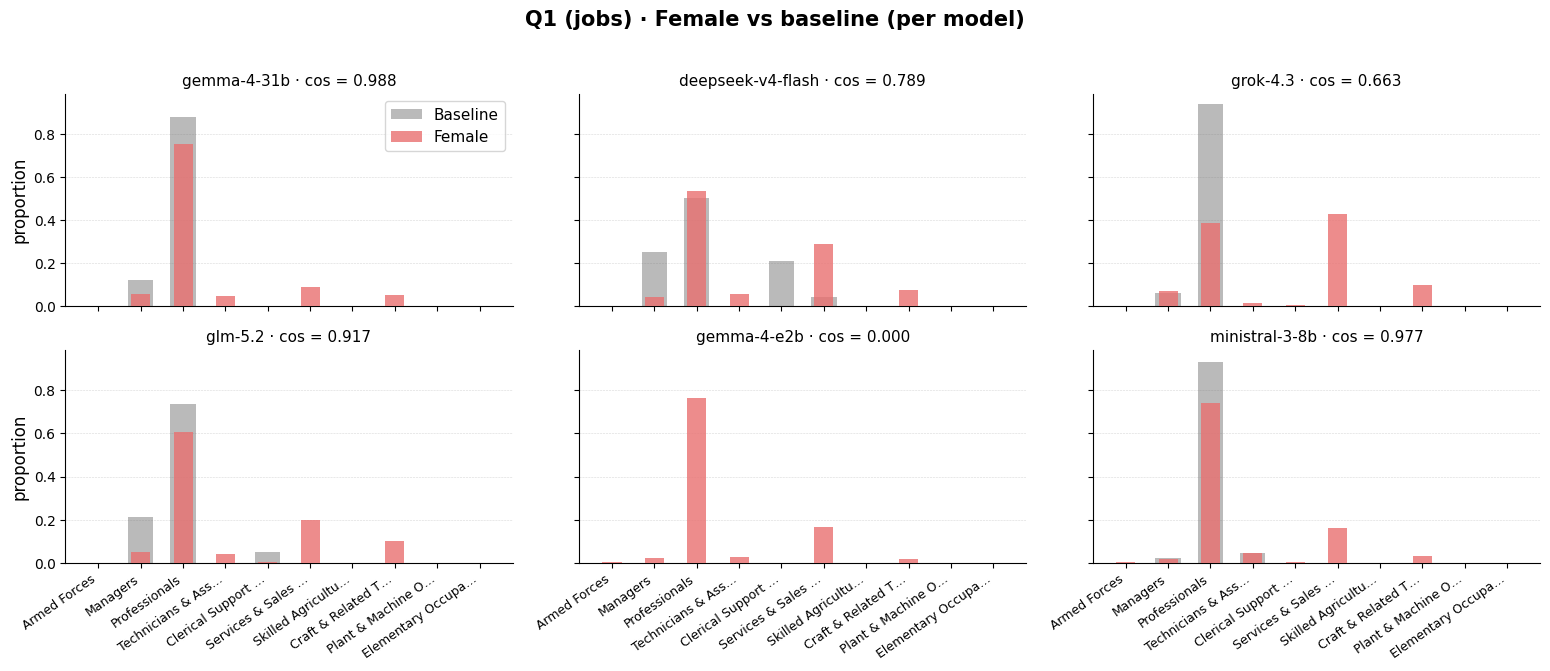

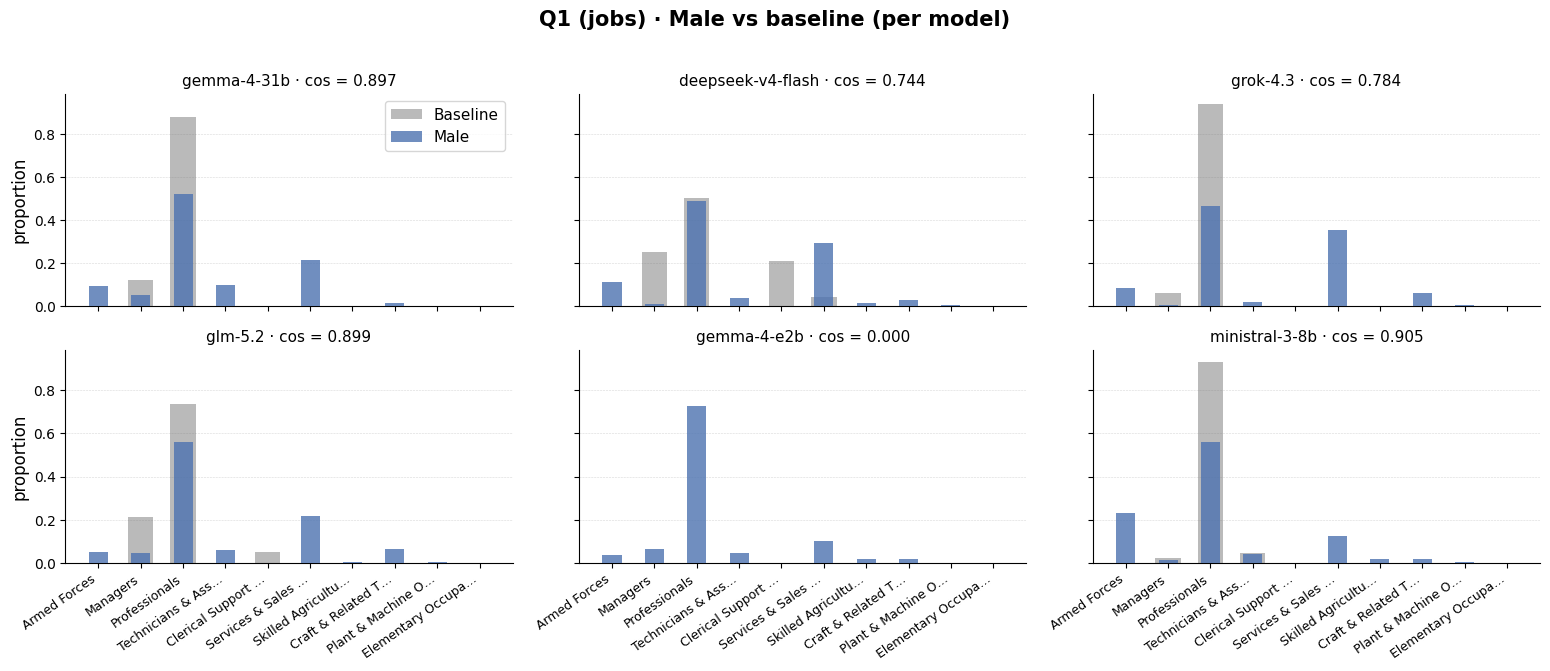

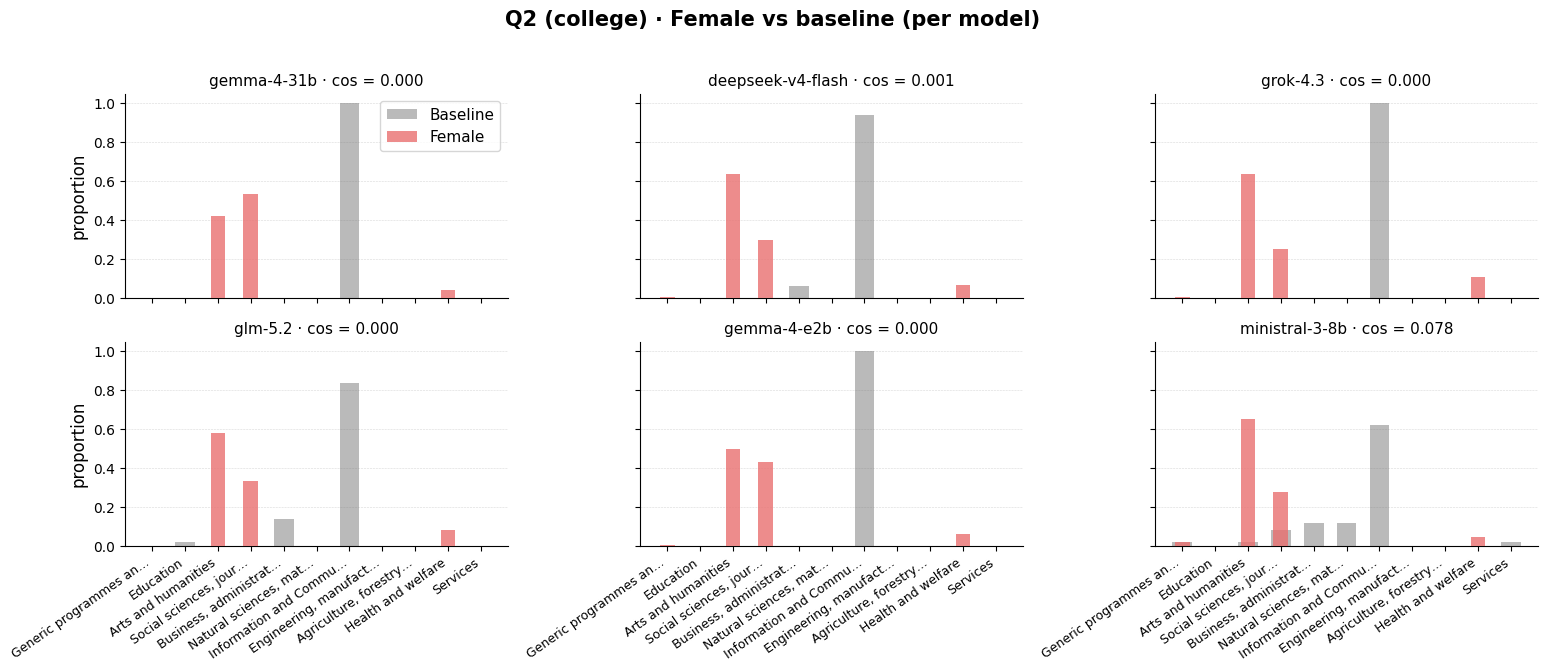

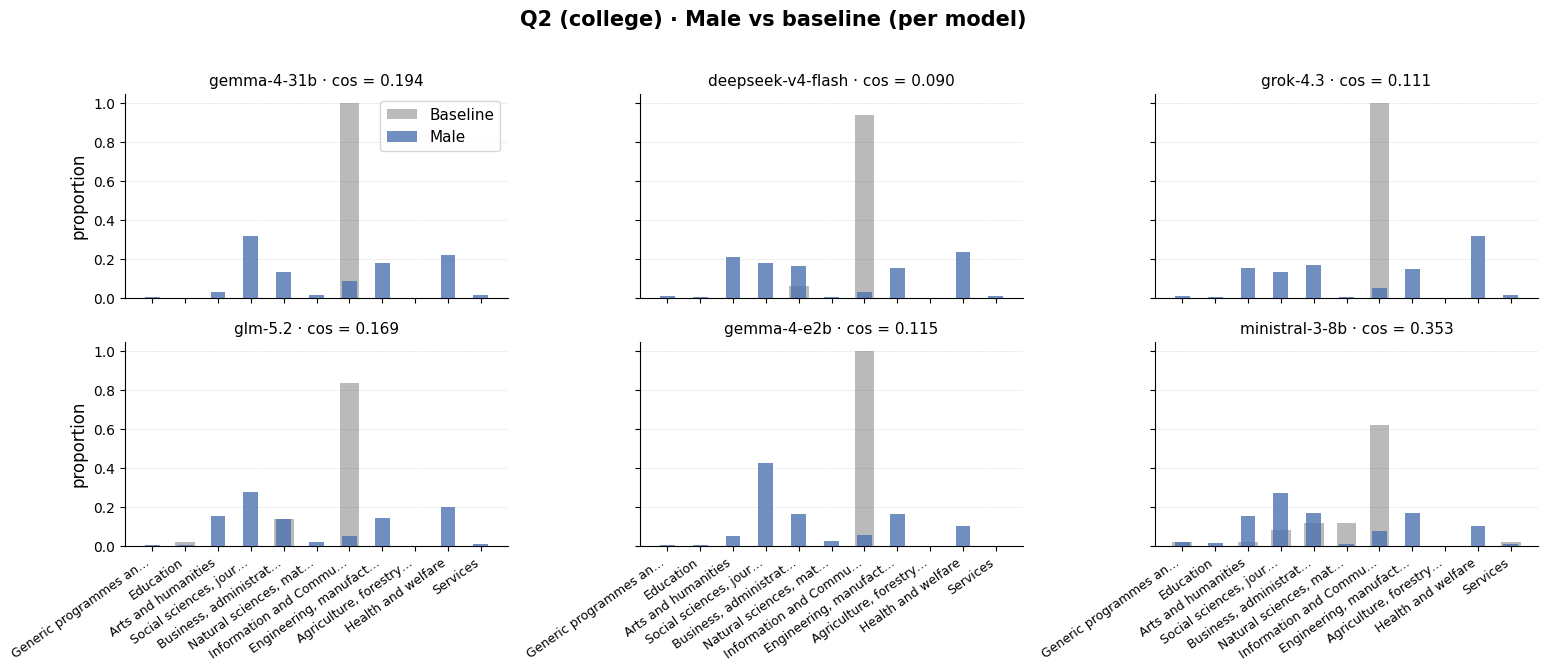

In [318]:
# --- Per-model gender vs. baseline overlays (per-model, not merged) ---
# One figure per (question, gender): 2×3 grid of models, each panel titled with its cosine
# similarity. Reuses _prob_vec / _cosine / BASE_C / MALE_C / FEMALE_C / MODEL_LABELS above.

def _model_vec(df, model, group_col, levels):
    return _prob_vec(df[df["subject_model_alias"] == model], group_col, levels)


def _gender_grid_per_variant(df_b, df_f, group_col, levels, q_label, gender, top_c, label_max):
    models = [m for m in BASELINE_MODELS if m in df_f["subject_model_alias"].unique()]
    sub = df_f[df_f["true_gender"].astype(str).str.lower() == gender.lower()]
    labels = [l if len(l) <= label_max else l[:label_max - 1] + "…" for l in levels]
    xi = np.arange(len(levels))

    ncols = 3
    nrows = int(np.ceil(len(models) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.4 * nrows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()
    fig.suptitle(f"{q_label} · {gender} vs baseline (per model)", fontsize=15, fontweight="bold")

    for mi, model in enumerate(models):
        ax = axes[mi]
        v_base = _model_vec(df_b, model, group_col, levels)
        v_top = _model_vec(sub, model, group_col, levels)
        cos_val = _cosine(v_base, v_top)
        ax.bar(xi, v_base, width=0.6, color=BASE_C, alpha=0.45, label="Baseline", zorder=2)
        ax.bar(xi, v_top, width=0.45, color=top_c, alpha=0.80, label=gender, zorder=3)
        ax.set_title(f"{MODEL_LABELS[model]} · cos = {cos_val:.3f}", fontsize=11)
        ax.set_xticks(xi)
        ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
        ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        if mi % ncols == 0:
            ax.set_ylabel("proportion", fontsize=12)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    axes[0].legend(fontsize=11, loc="upper right")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


for q_label, df_b, df_f, gcol, lv, lmax in [
    ("Q1 (jobs)", df_b_q1, df_f_q1, "major_group", levels_q1, 18),
    ("Q2 (college)", df_b_q2, df_f_q2, "broad_field", levels_q2, 22),
]:
    _gender_grid_per_variant(df_b, df_f, gcol, lv, q_label, "Female", FEMALE_C, lmax)
    _gender_grid_per_variant(df_b, df_f, gcol, lv, q_label, "Male", MALE_C, lmax)

#### Per-model region vectors vs. baseline

Per-model region grouped bars: a 2×3 model grid per question. Each panel gives one bar
per region (that model only), with the model's own persona-free baseline drawn as a black
tick per category. Q1 (jobs) and Q2 (college).

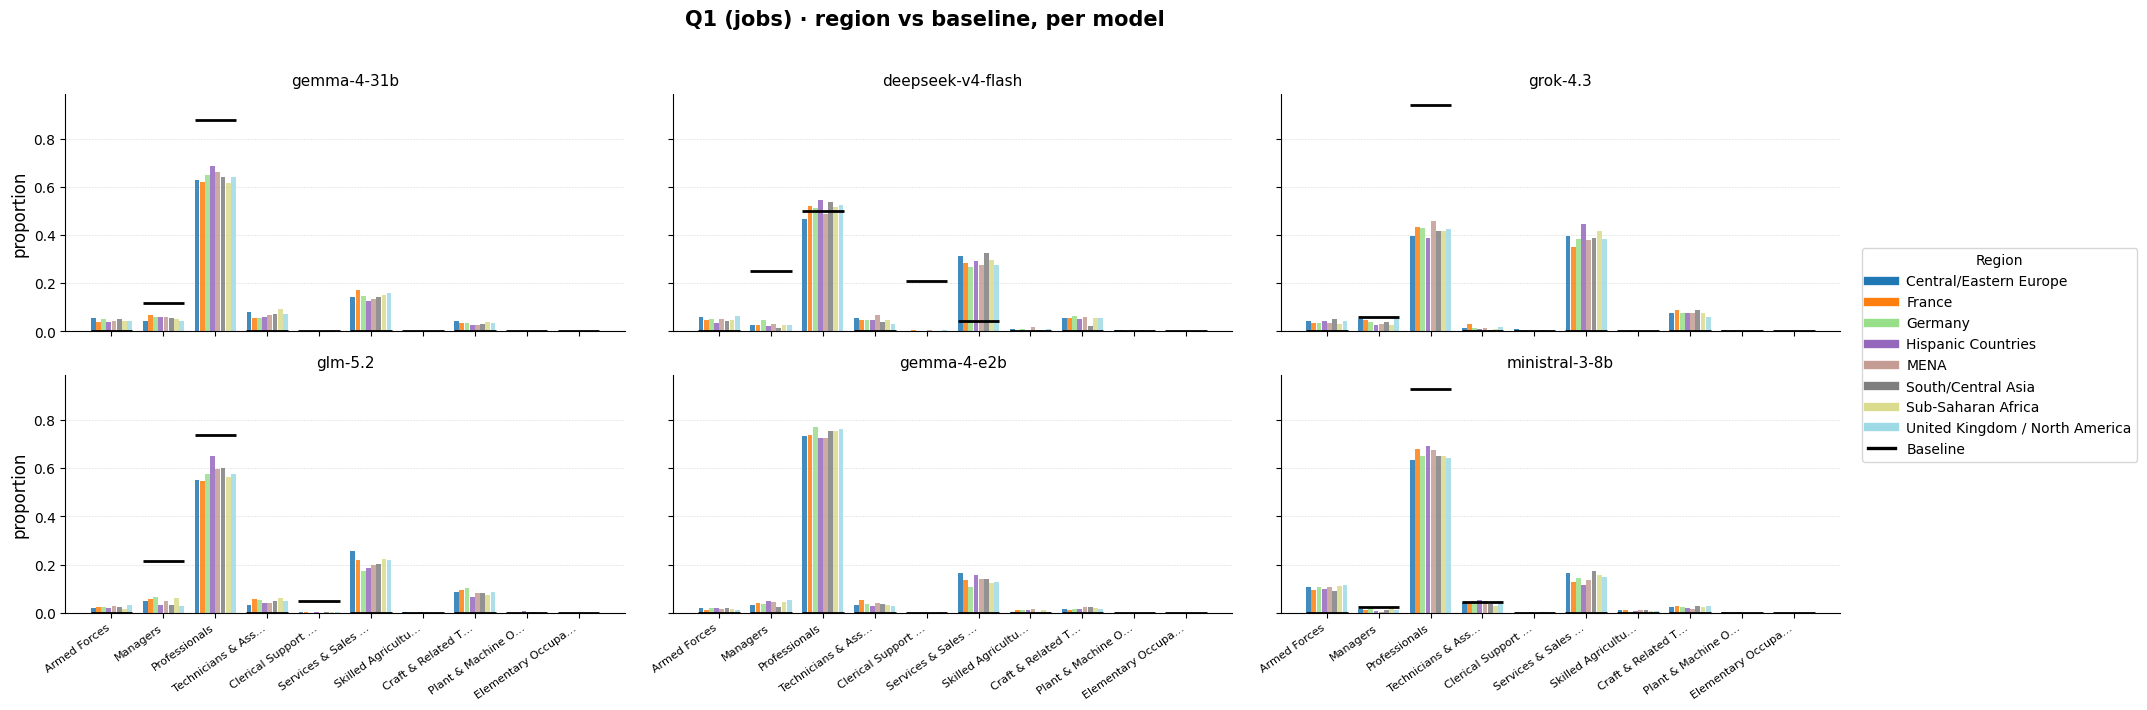

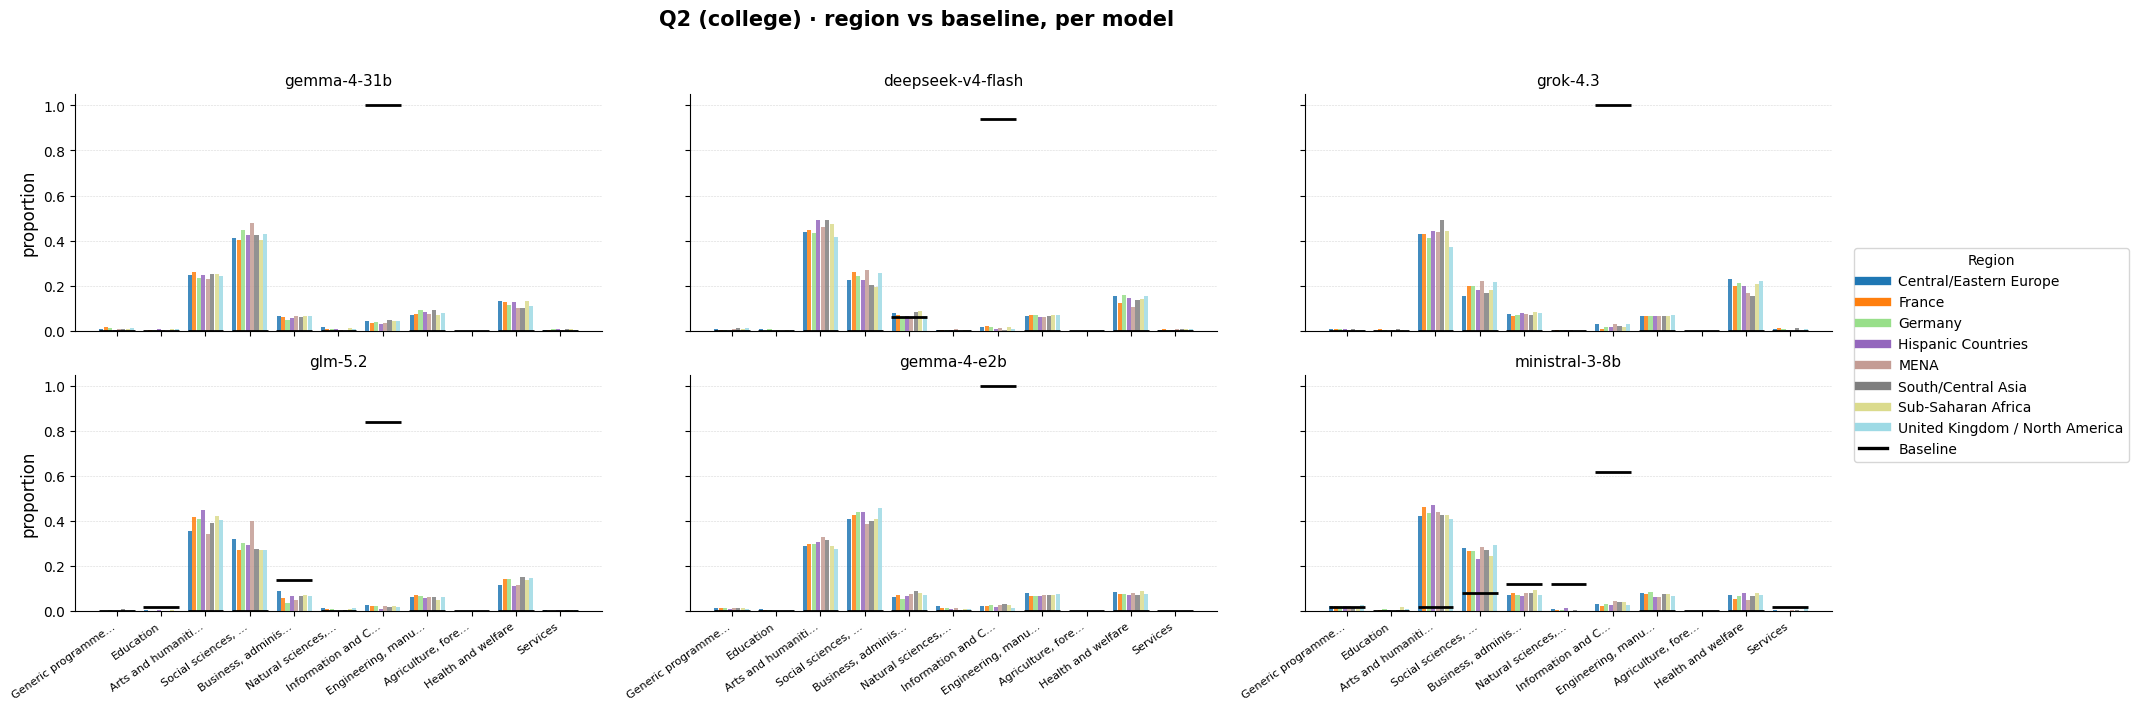

In [319]:
# --- Per-model region grouped bars vs. baseline (per-model, not merged) ---
# 2×3 model grid per question; each panel = one bar per region (that model only) + the
# model's own baseline tick. Reuses _prob_vec / MODEL_LABELS / BASELINE_MODELS.
from matplotlib.lines import Line2D as _L2D

REGION_CMAP = plt.cm.tab20


def _model_region_vectors(df_f, model, group_col, levels):
    """region -> that single model's proportion vector over `levels`."""
    sub = df_f[df_f["subject_model_alias"] == model]
    regions = sorted(df_f["true_race"].dropna().unique())
    return regions, {reg: _prob_vec(sub[sub["true_race"] == reg], group_col, levels)
                     for reg in regions}


def _draw_model_region_panel(ax, df_b, df_f, model, group_col, levels, short_lvls):
    regions, vecs = _model_region_vectors(df_f, model, group_col, levels)
    v_base = _prob_vec(df_b[df_b["subject_model_alias"] == model], group_col, levels)
    n_reg = len(regions)
    mat = np.array([vecs[r] for r in regions])
    xi = np.arange(len(levels))
    bar_w = 0.8 / n_reg
    half = 0.4
    for ri, reg in enumerate(regions):
        offset = (ri - n_reg / 2 + 0.5) * bar_w
        ax.bar(xi + offset, mat[ri], width=bar_w * 0.92,
               color=REGION_CMAP(ri / max(n_reg - 1, 1)), alpha=0.85,
               label=reg, zorder=2)
    for i_lev, b_val in enumerate(v_base):
        ax.plot([xi[i_lev] - half, xi[i_lev] + half], [b_val, b_val],
                color="black", linewidth=2.0, solid_capstyle="butt", zorder=6)
    ax.set_xticks(xi)
    ax.set_xticklabels(short_lvls, rotation=35, ha="right", fontsize=8)
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    return regions


def _region_legend_handles(regions):
    handles = [_L2D([0], [0], color=REGION_CMAP(ri / max(len(regions) - 1, 1)), lw=6)
               for ri in range(len(regions))]
    handles.append(_L2D([0], [0], color="black", lw=2.4))
    labels = list(regions) + ["Baseline"]
    return handles, labels


def _region_grid_per_q(df_b, df_f, group_col, levels, q_label):
    models = [m for m in BASELINE_MODELS if m in df_f["subject_model_alias"].unique()]
    short_lvls = [l if len(l) <= 18 else l[:17] + "…" for l in levels]
    ncols = 3
    nrows = int(np.ceil(len(models) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 3.6 * nrows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()
    fig.suptitle(f"{q_label} · region vs baseline, per model", fontsize=15, fontweight="bold")
    regions = None
    for mi, model in enumerate(models):
        regions = _draw_model_region_panel(axes[mi], df_b, df_f, model, group_col, levels, short_lvls)
        axes[mi].set_title(MODEL_LABELS[model], fontsize=11)
        if mi % ncols == 0:
            axes[mi].set_ylabel("proportion", fontsize=12)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    h, l = _region_legend_handles(regions)
    fig.legend(handles=h, labels=l, fontsize=10, loc="center left",
               bbox_to_anchor=(1.0, 0.5), frameon=True, title="Region")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


for q_label, df_b, df_f, gcol, lv in [
    ("Q1 (jobs)", df_b_q1, df_f_q1, "major_group", levels_q1),
    ("Q2 (college)", df_b_q2, df_f_q2, "broad_field", levels_q2),
]:
    _region_grid_per_q(df_b, df_f, gcol, lv, q_label)


## Behavioral Audit - Model-Specific

### Gender

In [320]:
"""
Combines *_category_tests.csv files (per-model significance tests) into a single DataFrame.
"""

import re
from pathlib import Path

import pandas as pd

UNPREFIXED_NAME = re.compile(r"^q\d+_.*__category_tests\.csv$")


def combine_significance(root_dir: Path) -> pd.DataFrame:
    all_files = sorted(root_dir.glob("significance_*/*category_tests*.csv"))
    if not all_files:
        all_files = sorted(root_dir.rglob("*category_tests*.csv"))

    files = [f for f in all_files if UNPREFIXED_NAME.match(f.name)]
    skipped = [f for f in all_files if f not in files]
    if skipped:
        print(f"Skipped {len(skipped)} files with a model prefix (not combined).")

    if not files:
        print(f"No unprefixed *category_tests*.csv found inside {root_dir}")
        return pd.DataFrame()

    combined = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

    key_cols = ["question_key", "model_alias", "attribute", "category_value", "group_value"]
    before = len(combined)
    combined = combined.drop_duplicates(subset=key_cols, keep="first")
    if len(combined) < before:
        print(f"Removed {before - len(combined)} duplicate rows (files repeated with/without prefix).")

    combined = combined.sort_values(
        ["model_alias", "question_key", "attribute", "category_value", "group_value"]
    ).reset_index(drop=True)

    return combined


root_dir = Path("experiments/behavioral_audit/results_behavioral_audit/results_merged/frequency_tables")
combined_df = combine_significance(root_dir)

n_before = len(combined_df)
combined_df = combined_df[combined_df["model_alias"] != "all_models"].reset_index(drop=True)
print(f"Excluded {n_before - len(combined_df)} rows from 'all_models' (pooled test, not a model).")
print(f"Combined in-memory: {len(combined_df)} rows")

Excluded 560 rows from 'all_models' (pooled test, not a model).
Combined in-memory: 2840 rows


In [321]:
from pathlib import Path
import numpy as np
import pandas as pd

OUTPUT_DIR = Path("experiments/behavioral_audit/model-comparison-results/figures")
TOP_N = 10
QUESTION_TITLES = {
    "q1": "Job Recommendation",
    "q2": "College Recommendation",
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [322]:
df = combined_df.copy()


In [323]:
def clean_model(name: str) -> str:
    return name.replace("_paid", "").replace("_modal", "")


def prepare_gender_data(df: pd.DataFrame, question: str) -> pd.DataFrame:
    """Pivots Female/Male by (model, category) and computes the gap and log2(OR) Female vs Male."""
    sub = df[(df["question_key"] == question) & (df["attribute"] == "Gender")].copy()
    if sub.empty:
        return sub

    fem = sub[sub["group_value"] == "Female"].set_index(["model_alias", "category_value"])
    mal = sub[sub["group_value"] == "Male"].set_index(["model_alias", "category_value"])

    idx = fem.index.intersection(mal.index)
    out = pd.DataFrame(index=idx)
    out["f_in"] = fem.loc[idx, "group_in_category"]
    out["f_out"] = fem.loc[idx, "group_outside_category"]
    out["m_in"] = mal.loc[idx, "group_in_category"]
    out["m_out"] = mal.loc[idx, "group_outside_category"]
    out["category_total"] = fem.loc[idx, "category_total"]

    # Gap: (F - M) / (F + M) within the category, in %
    denom = (out["f_in"] + out["m_in"]).replace(0, np.nan)
    out["gap_pct"] = (out["f_in"] - out["m_in"]) / denom * 100

    # log2 odds ratio Female vs Male, Haldane correction (+0.5)
    a, b = out["f_in"] + 0.5, out["f_out"] + 0.5
    c, d = out["m_in"] + 0.5, out["m_out"] + 0.5
    out["log2_or"] = np.log2((a / b) / (c / d))

    # Significant if the Female test (FDR) rejects H0
    out["significant"] = fem.loc[idx, "reject_fdr"].astype(bool)

    return out.reset_index()

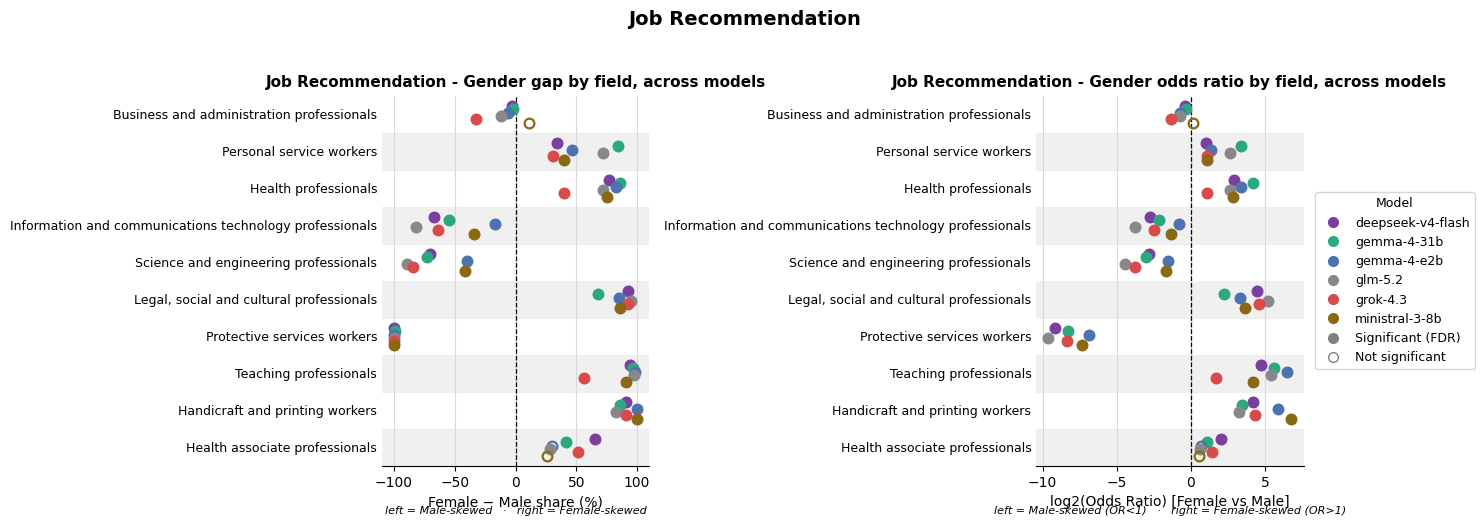

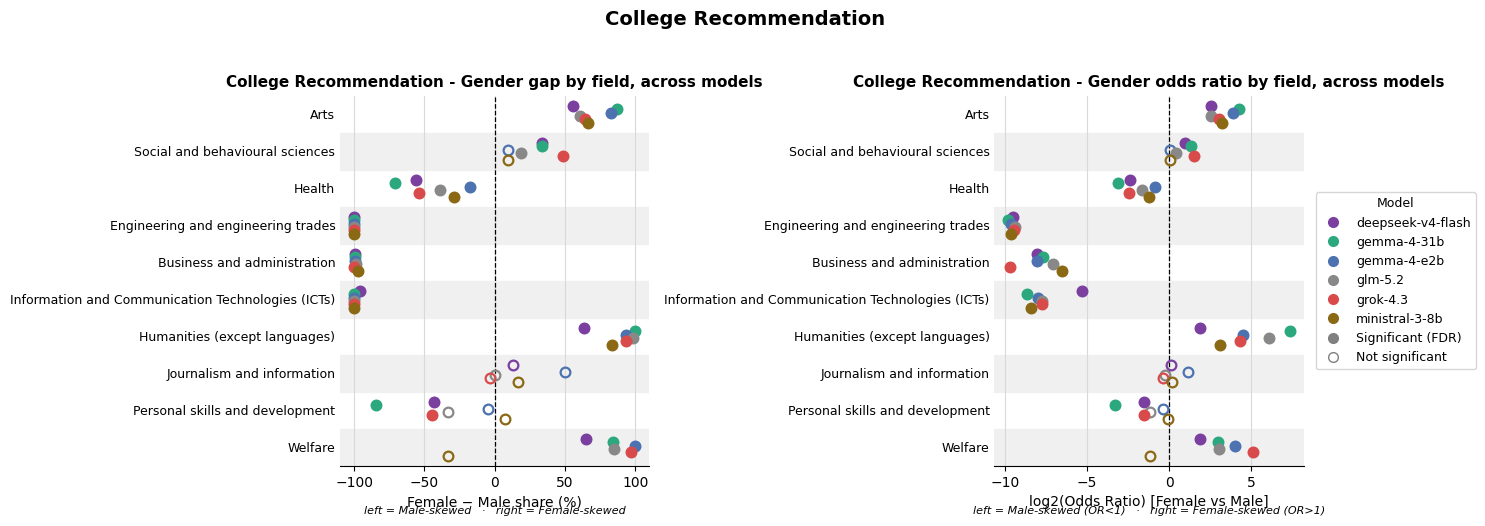

In [324]:
from matplotlib.lines import Line2D

def dot_panel(ax, data, categories, models, x_col, xlabel, footnote):
    n_models = len(models)
    total_span = 0.45
    offsets = np.linspace(total_span / 2, -total_span / 2, n_models) if n_models > 1 else [0.0]

    y_base = {cat: i for i, cat in enumerate(reversed(categories))}

    for i in range(len(categories)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

    for mi, model in enumerate(models):
        color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
        mdata = data[data["model_alias"] == model]
        for _, row in mdata.iterrows():
            if row["category_value"] not in y_base:
                continue
            y = y_base[row["category_value"]] + offsets[mi]
            sig = bool(row["significant"])
            ax.plot(
                row[x_col], y,
                marker="o", linestyle="none", markersize=7,
                markerfacecolor=color if sig else "none",
                markeredgecolor=color, markeredgewidth=1.6,
                zorder=3,
            )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.9, zorder=2)
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(list(reversed(categories)), fontsize=9)
    ax.set_ylim(-0.5, len(categories) - 0.5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.grid(axis="x", color="0.85", zorder=1)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.annotate(footnote, xy=(0.5, -0.13), xycoords="axes fraction",
                ha="center", fontsize=8, style="italic")

def make_figure(df: pd.DataFrame, question: str):
    data = prepare_gender_data(df, question)
    if data.empty:
        print(f"[!] No Gender data for {question}, skipping.")
        return

    top_cats = (
        data.groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )
    data = data[data["category_value"].isin(top_cats)]
    models = sorted(data["model_alias"].unique())
    title = QUESTION_TITLES.get(question, question)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    dot_panel(axes[0], data, top_cats, models, "gap_pct",
              "Female − Male share (%)",
              "left = Male-skewed   ·   right = Female-skewed")
    axes[0].set_title(f"{title} - Gender gap by field, across models",
                      fontsize=11, fontweight="bold")

    dot_panel(axes[1], data, top_cats, models, "log2_or",
              "log2(Odds Ratio) [Female vs Male]",
              "left = Male-skewed (OR<1)   ·   right = Female-skewed (OR>1)")
    axes[1].set_title(f"{title} - Gender odds ratio by field, across models",
                      fontsize=11, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    axes[1].legend(handles=handles, title="Model", loc="center left",
                   bbox_to_anchor=(1.02, 0.5), fontsize=9, title_fontsize=9)

    fig.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.show()

for q in sorted(df["question_key"].unique()):
    make_figure(df, q)


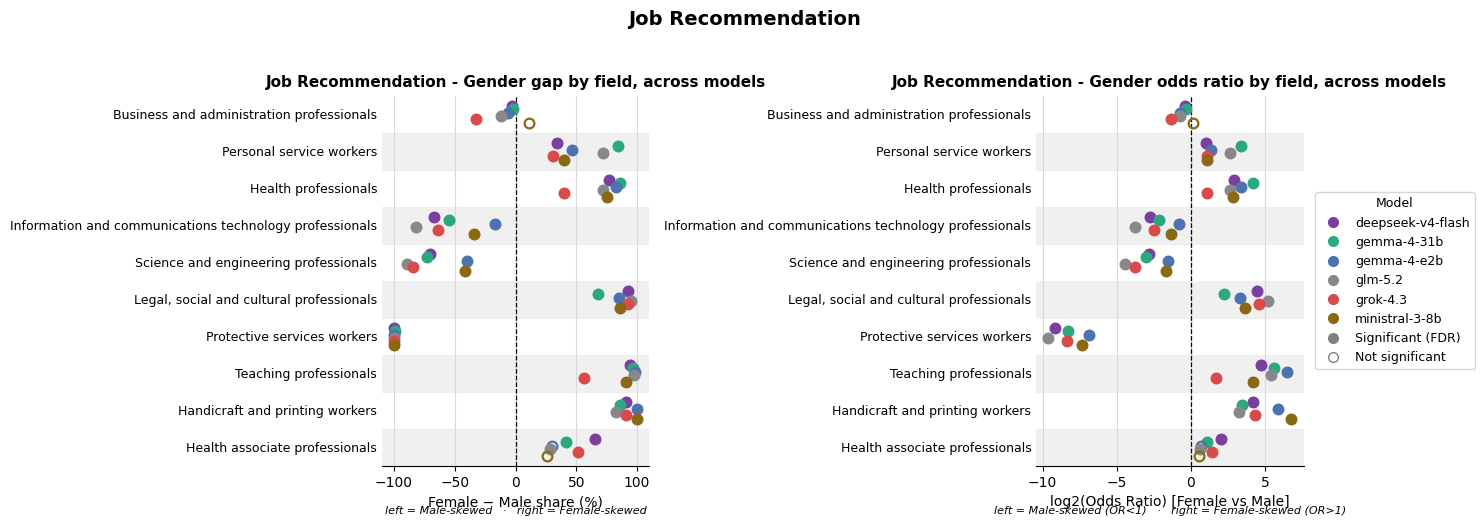

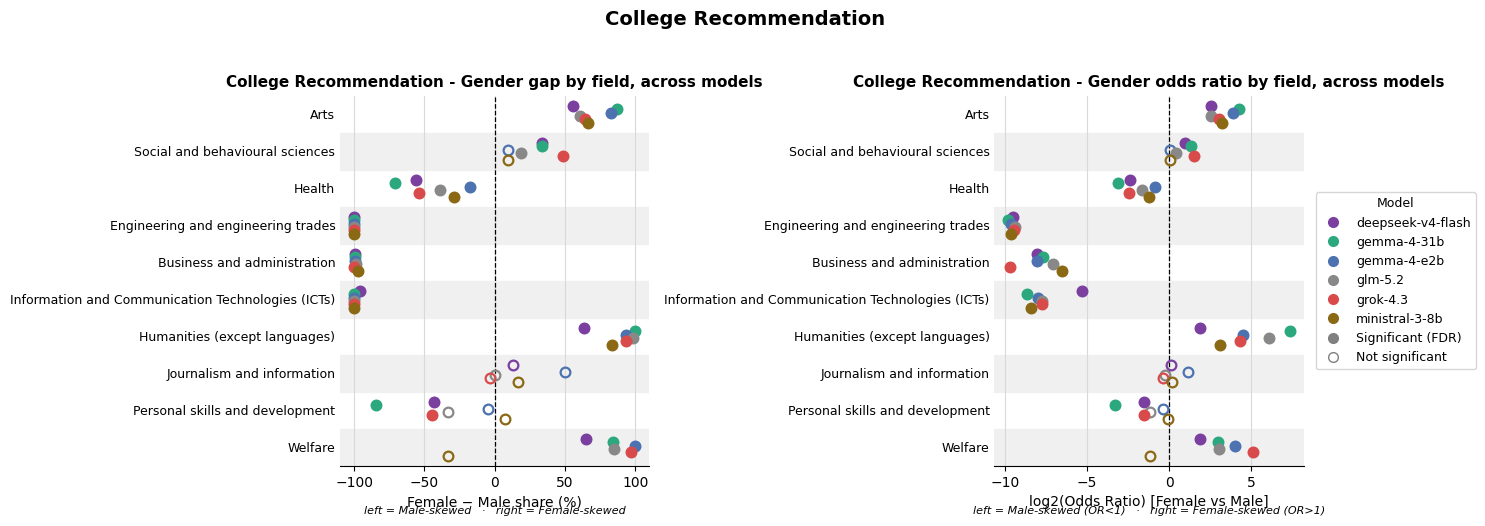

In [325]:
for q in sorted(df["question_key"].unique()):
    make_figure(df, q)

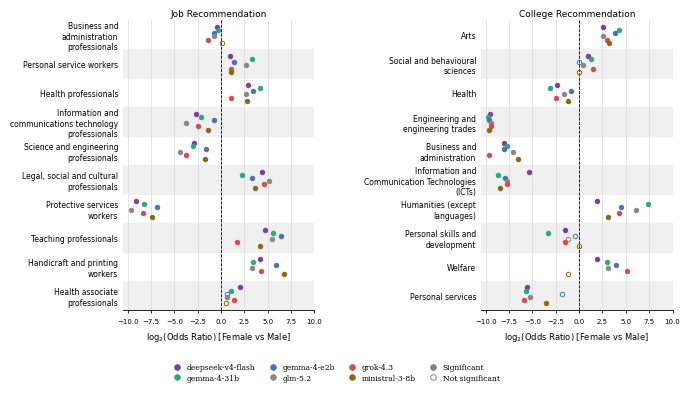

In [326]:
import textwrap
from matplotlib.lines import Line2D

ACM_TEXT_WIDTH_IN = 7.0
ACM_LABEL_WRAP = 26
ACM_XLIM = (-10.5, 10)
ROW_H = 0.28
PANEL_SHRINK = 0.90
FS_YLABEL = 5.5
FS_XTICK = 5.0
FS_XLABEL = 6.0
FS_TITLE = 6.5
FS_LEGEND = 5.5


def dot_panel_acm_wide(ax, data, categories, models, x_col, xlim=None):
    n_models = len(models)
    total_span = 0.55
    offsets = np.linspace(total_span / 2, -total_span / 2, n_models) if n_models > 1 else [0.0]

    y_base = {cat: i for i, cat in enumerate(reversed(categories))}

    for i in range(len(categories)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

    for mi, model in enumerate(models):
        color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
        mdata = data[data["model_alias"] == model]
        for _, row in mdata.iterrows():
            if row["category_value"] not in y_base:
                continue
            y = y_base[row["category_value"]] + offsets[mi]
            sig = bool(row["significant"])
            ax.plot(
                row[x_col], y,
                marker="o", linestyle="none", markersize=3.2,
                markerfacecolor=color if sig else "none",
                markeredgecolor=color, markeredgewidth=0.7,
                zorder=3,
            )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.6, zorder=2)
    ax.set_yticks(range(len(categories)))
    wrapped = [textwrap.fill(c, ACM_LABEL_WRAP) for c in reversed(categories)]
    ax.set_yticklabels(wrapped, fontsize=FS_YLABEL)
    ax.set_ylim(-0.5, len(categories) - 0.5)
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.set_xlabel("log$_2$(Odds Ratio) [Female vs Male]", fontsize=FS_XLABEL)
    ax.tick_params(axis="x", labelsize=FS_XTICK, width=0.6, length=2.5)
    ax.grid(axis="x", color="0.85", zorder=1, linewidth=0.5)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.tick_params(axis="y", length=0)


def make_or_figure_acm_combined(df: pd.DataFrame, top_n: int = TOP_N):
    questions = sorted(df["question_key"].unique())

    panels = []
    all_models = set()
    for q in questions:
        data = prepare_gender_data(df, q)
        if data.empty:
            print(f"[!] No Gender data for {q}, skipping combined figure.")
            return
        models = sorted(data["model_alias"].unique())
        all_models.update(models)

        counts = data.groupby("category_value")["model_alias"].nunique()
        shared_cats = counts[counts == len(models)].index
        top_cats = (
            data[data["category_value"].isin(shared_cats)]
            .groupby("category_value")["category_total"].sum()
            .sort_values(ascending=False).head(top_n).index.tolist()
        )
        panels.append((q, data[data["category_value"].isin(top_cats)], top_cats, models))

    models_all = sorted(all_models)

    n_rows = max(len(p[2]) for p in panels)
    height = ROW_H * n_rows + 1.0
    fig, axes = plt.subplots(1, 2, figsize=(ACM_TEXT_WIDTH_IN, height))

    with plt.rc_context({"font.family": "serif"}):
        for ax, (q, data, cats, models) in zip(axes, panels):
            dot_panel_acm_wide(ax, data, cats, models, "log2_or", xlim=ACM_XLIM)
            ax.set_title(QUESTION_TITLES.get(q, q), fontsize=FS_TITLE, pad=3)

        handles = [
            Line2D([], [], marker="o", linestyle="none", markersize=4,
                   markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
                   markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
                   markeredgewidth=0.7, label=clean_model(m))
            for i, m in enumerate(models_all)
        ]
        handles += [
            Line2D([], [], marker="o", linestyle="none", markersize=4,
                   markerfacecolor="gray", markeredgecolor="gray",
                   markeredgewidth=0.7, label="Significant"),
            Line2D([], [], marker="o", linestyle="none", markersize=4,
                   markerfacecolor="none", markeredgecolor="gray",
                   markeredgewidth=0.7, label="Not significant"),
        ]
        fig.legend(
            handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.0),
            ncol=4, fontsize=FS_LEGEND, frameon=False,
            handletextpad=0.3, columnspacing=1.2, labelspacing=0.3,
            borderaxespad=0.0,
        )

    fig.tight_layout(pad=0.3, w_pad=1.5, rect=(0, 0.10, 1, 1))

    p0, p1 = axes[0].get_position(), axes[1].get_position()
    w = min(p0.width, p1.width) * PANEL_SHRINK
    axes[0].set_position([p0.x1 - w, p0.y0, w, p0.height])
    axes[1].set_position([p1.x1 - w, p1.y0, w, p1.height])

    plt.show()


make_or_figure_acm_combined(df)


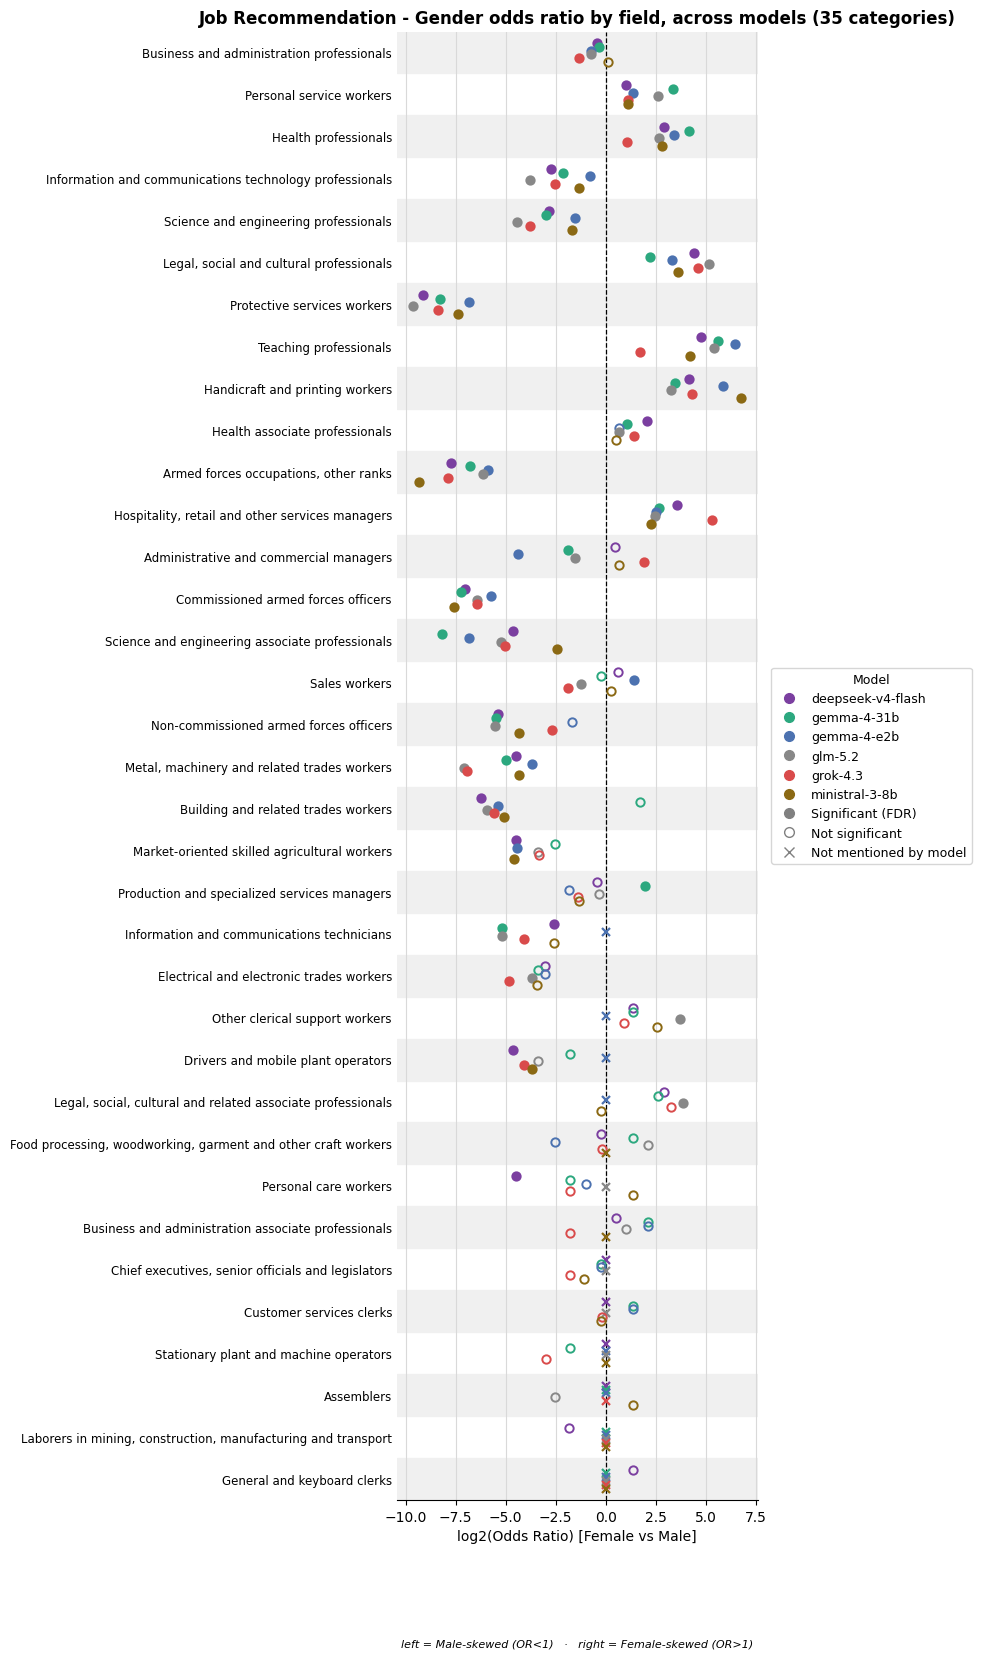

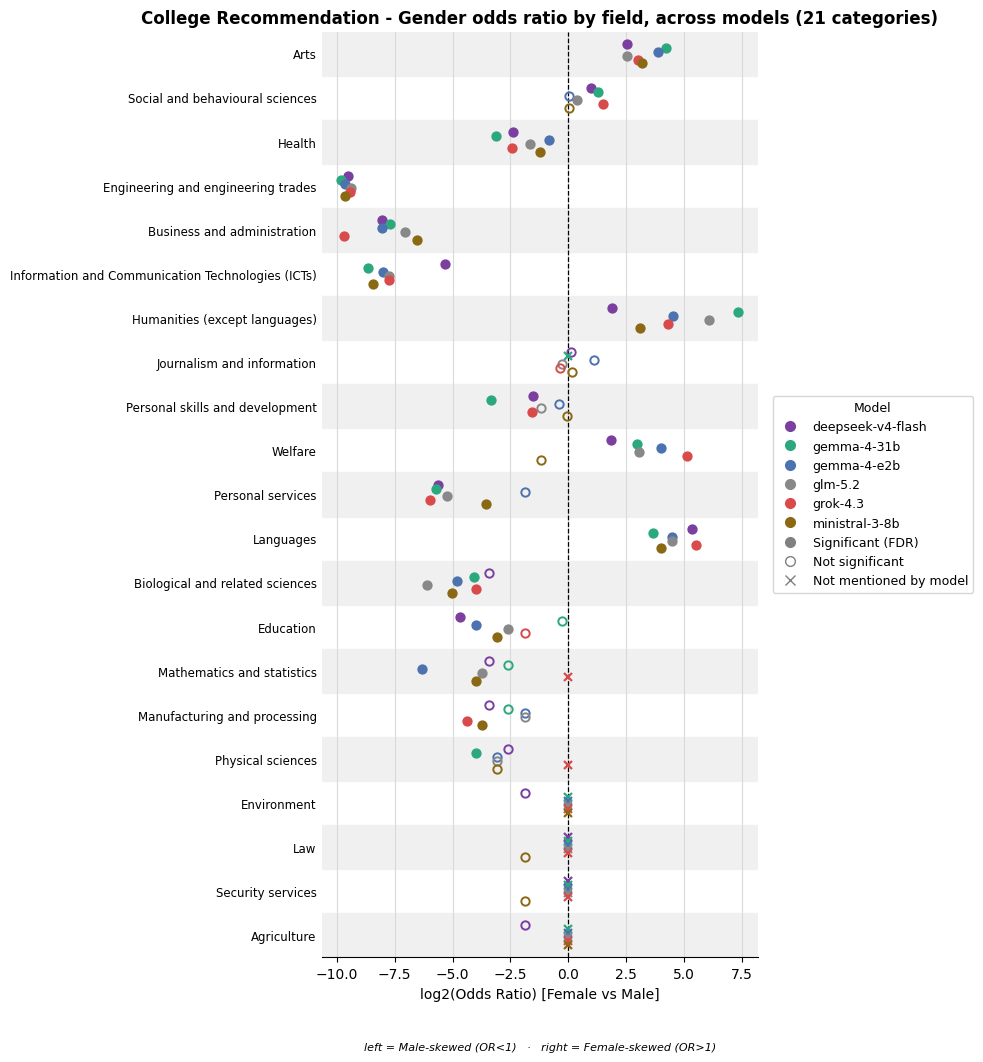

In [327]:
def dot_panel_all(ax, data, categories, models, x_col, xlabel, footnote):
    n_models = len(models)
    total_span = 0.45
    offsets = np.linspace(total_span / 2, -total_span / 2, n_models) if n_models > 1 else [0.0]

    y_base = {cat: i for i, cat in enumerate(reversed(categories))}

    for i in range(len(categories)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

    for mi, model in enumerate(models):
        color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
        mdata = data[data["model_alias"] == model]
        for _, row in mdata.iterrows():
            if row["category_value"] not in y_base:
                continue
            y = y_base[row["category_value"]] + offsets[mi]

            if row.get("missing", False):
                ax.plot(0.0, y, marker="x", linestyle="none",
                        markersize=6, markeredgecolor=color,
                        markeredgewidth=1.6, zorder=3)
            else:
                sig = bool(row["significant"])
                ax.plot(row[x_col], y, marker="o", linestyle="none",
                        markersize=6,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.4,
                        zorder=3)

    ax.axvline(0, color="black", linestyle="--", linewidth=0.9, zorder=2)
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(list(reversed(categories)), fontsize=8.5)
    ax.set_ylim(-0.5, len(categories) - 0.5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.grid(axis="x", color="0.85", zorder=1)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.annotate(footnote, xy=(0.5, -0.1), xycoords="axes fraction",
                ha="center", fontsize=8, style="italic")


def make_or_figure_all(df: pd.DataFrame, question: str):
    data = prepare_gender_data(df, question)
    if data.empty:
        print(f"[!] No Gender data for {question}, skipping.")
        return

    models = sorted(data["model_alias"].unique())

    cats = (
        data.groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).index.tolist()
    )

    data["missing"] = False
    existing = set(zip(data["model_alias"], data["category_value"]))
    missing = [
        {"model_alias": m, "category_value": c, "log2_or": 0.0,
         "significant": False, "missing": True}
        for m in models for c in cats if (m, c) not in existing
    ]
    if missing:
        data = pd.concat([data, pd.DataFrame(missing)], ignore_index=True)

    title = QUESTION_TITLES.get(question, question)
    height = max(5.0, 0.42 * len(cats) + 1.8)
    fig, ax = plt.subplots(figsize=(10, height))

    dot_panel_all(ax, data, cats, models, "log2_or",
                  "log2(Odds Ratio) [Female vs Male]",
                  "left = Male-skewed (OR<1)   ·   right = Female-skewed (OR>1)")
    ax.set_title(f"{title} - Gender odds ratio by field, across models ({len(cats)} categories)",
                 fontsize=12, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
        Line2D([], [], marker="x", linestyle="none", markersize=7,
               markeredgecolor="gray", label="Not mentioned by model"),
    ]
    ax.legend(handles=handles, title="Model", loc="center left",
              bbox_to_anchor=(1.02, 0.5), fontsize=9, title_fontsize=9)

    fig.tight_layout()
    plt.show()


for q in sorted(df["question_key"].unique()):
    make_or_figure_all(df, q)


#### Findings tables — top gender-skewed categories

For each category, the favored class (Male/Female), category count $n_{cat}$, odds ratio,
and FDR-adjusted p-value — sorted by significance. Pools the per-model significance tests
(`combined_df`); one row per category, taking the strongest (lowest-$p_{adj}$) finding.

In [328]:
from IPython.display import display

# The paper's findings tables come from the POOLED "all_models" significance tests
# (caption: "across all models"), which combined_df deliberately excludes. Read those
# files directly. Per category the paper reports the FAVORED class — the over-represented
# side (odds ratio >= 1) — not simply the lowest-p row.
_SIG_DIR = (BA_REPO_ROOT / "experiments" / "behavioral_audit" / "results_behavioral_audit"
            / "results_merged" / "frequency_tables" / "significance_tests" / "all_models")


def findings_table(qattr, top_n=8, significant_only=False):
    """qattr e.g. 'q1_gender' / 'q2_race'. One row per category = favored (OR>=1) class,
    sorted by adjusted p-value; mirrors the paper's findings tables."""
    path = _SIG_DIR / f"{qattr}__category_tests.csv"
    rows = pd.read_csv(path)
    if significant_only:
        rows = rows[rows["reject_fdr"].astype(str).str.lower().isin(["true", "1"])]
    if rows.empty:
        print(f"[!] No rows for {qattr}")
        return None
    rows = rows.copy()
    rows["_or"] = pd.to_numeric(rows["odds_ratio"], errors="coerce").fillna(0.0)
    # keep the over-represented side (OR >= 1) per category, strongest (lowest p) among those
    favored = rows[rows["_or"] >= 1.0].sort_values("corrected_p_value")
    favored = favored.drop_duplicates("category_value", keep="first")
    favored = favored.sort_values("corrected_p_value").head(top_n)

    def _fmt_or(x):
        return "∞" if not np.isfinite(x) else f"{x:.1f}"

    def _fmt_p(x):
        x = float(x)
        return "<1e-300" if x == 0 else f"{x:.2g}"

    def _stars(p):
        p = float(p)
        return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else ""

    return pd.DataFrame({
        "Category": favored["category_value"].values,
        "Class": favored["group_value"].values,
        "n_cat": favored["category_total"].astype(int).values,
        "OR": [_fmt_or(v) for v in favored["_or"].values],
        "p_adj": [_fmt_p(v) for v in favored["corrected_p_value"].values],
        "sig": [_stars(v) for v in favored["corrected_p_value"].values],
    }).reset_index(drop=True)


print("Top eight gender findings — Q1 (job recommendations)")
display(findings_table("q1_gender", top_n=8))

print("Top eight gender findings — Q2 (college major recommendations)")
display(findings_table("q2_gender", top_n=8))

Top eight gender findings — Q1 (job recommendations)


,Category,Class,n_cat,OR,p_adj,sig
0,Protective services workers,Male,1060,1378.9,<1e-300,***
1,Health professionals,Female,2589,8.2,<1e-300,***
2,"Legal, social and cultural professionals",Female,1237,16.6,3.9e-236,***
3,"Armed forces occupations, other ranks",Male,516,∞,5.6e-176,***
4,Teaching professionals,Female,782,17.9,2e-152,***
5,Information and communications technology prof...,Male,1610,4.4,2e-152,***
6,Science and engineering professionals,Male,1322,5.2,9.1e-151,***
7,Handicraft and printing workers,Female,745,15.6,2.5e-139,***


Top eight gender findings — Q2 (college major recommendations)


,Category,Class,n_cat,OR,p_adj,sig
0,Arts,Female,7720,7.8,<1e-300,***
1,Business and administration,Male,1604,251.6,<1e-300,***
2,Engineering and engineering trades,Male,1616,∞,<1e-300,***
3,Health,Male,2714,4.0,7.9e-226,***
4,Information and Communication Technologies (ICTs),Male,600,763.4,5.6e-207,***
5,Humanities (except languages),Female,526,19.0,3.6e-102,***
6,Social and behavioural sciences,Female,6917,1.5,1.4e-46,***
7,Personal services,Male,97,116.3,1.5e-31,***


### Region

In [329]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUTPUT_DIR = Path("experiments/behavioral_audit/model-comparison-results/figures").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 6
EXCLUDE_REGIONS = {"Unknown"}

QUESTION_TITLES = {
    "q1": "Job Recommendation",
    "q2": "College Recommendation",
}

def clean_model(name: str) -> str:
    return name.replace("_paid", "").replace("_modal", "")


In [330]:
df = combined_df.copy()


def prepare_region_data(df: pd.DataFrame, question: str) -> pd.DataFrame:
    """Region rows with the % of each region's outputs that fall into each category."""
    sub = df[(df["question_key"] == question) & (df["attribute"] == "Region")].copy()
    sub = sub[~sub["group_value"].isin(EXCLUDE_REGIONS)]

    # % of that region's outputs that fall into this category
    sub["share_pct"] = sub["group_in_category"] / sub["group_total"] * 100
    sub["significant"] = sub["reject_fdr"].astype(bool)
    sub = sub.rename(columns={"group_value": "region"})
    return sub


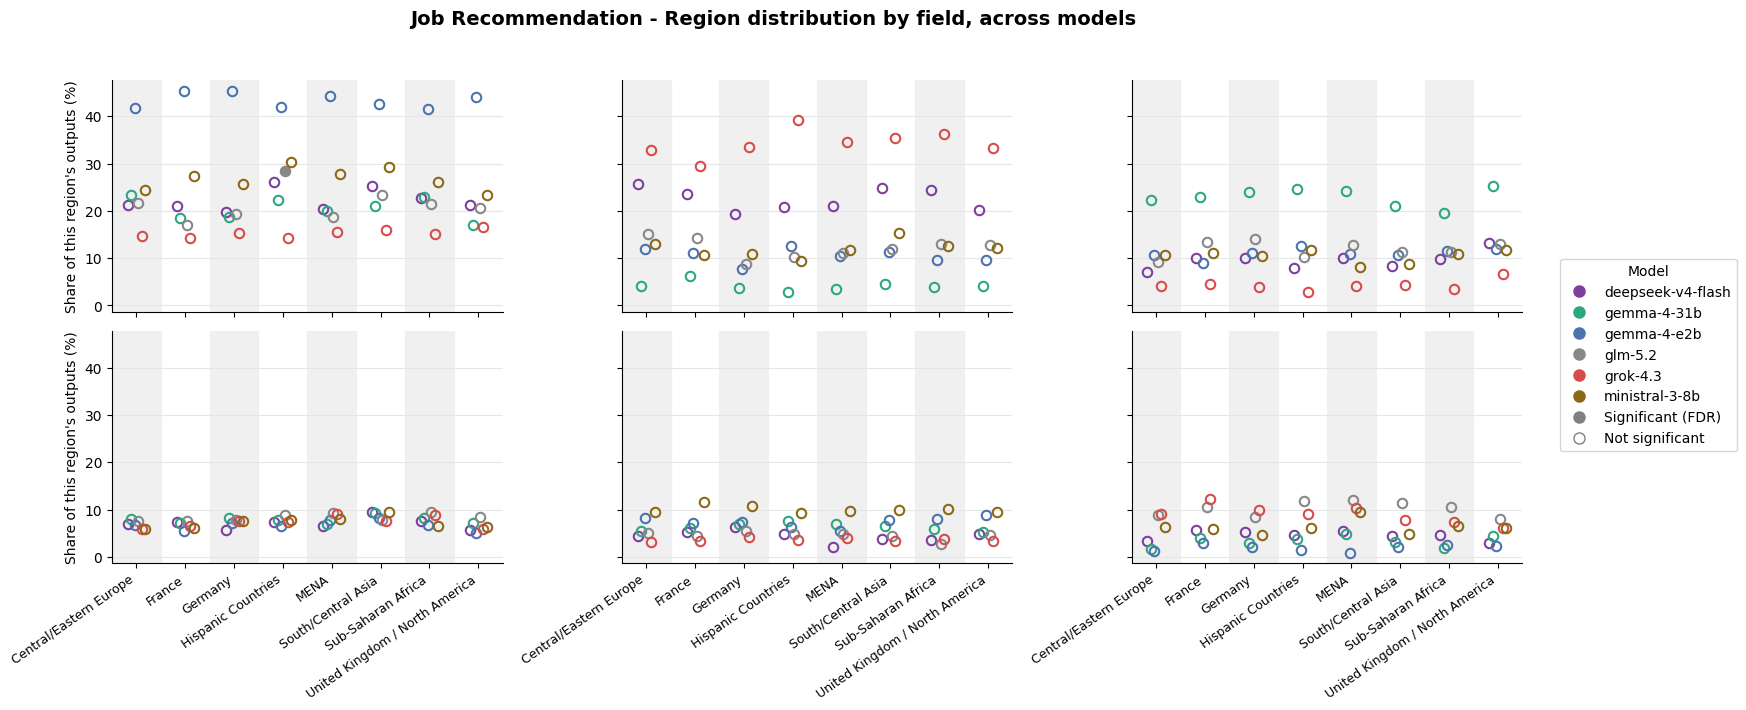

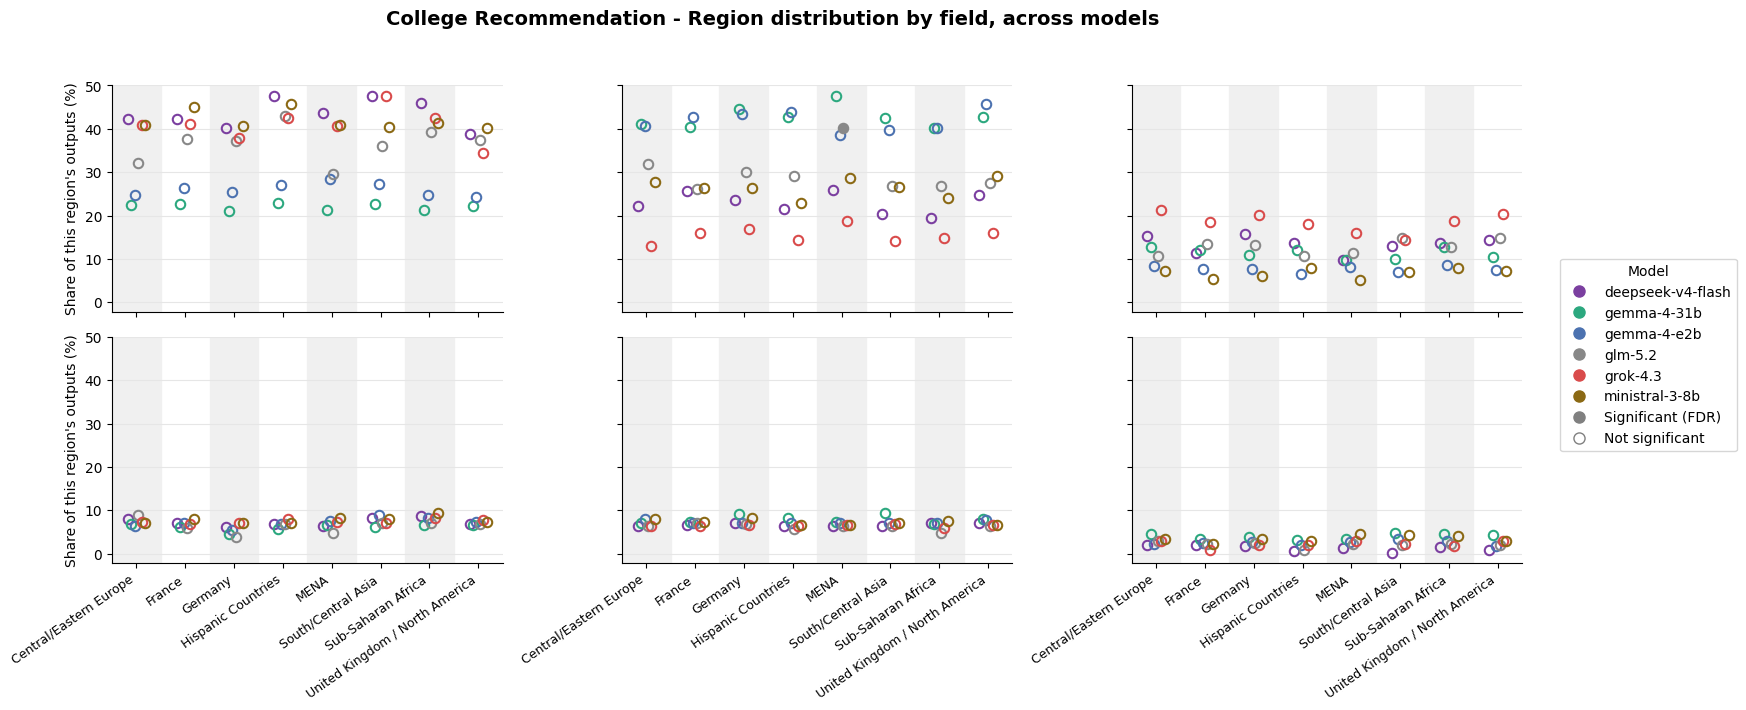

In [331]:
def region_smallmultiples(df: pd.DataFrame, question: str, n_cols=3):
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())

    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    top_cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )

    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(top_cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(top_cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["share_pct"], marker="o", linestyle="none",
                        markersize=6.8,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.5, zorder=3)

        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=35, ha="right", fontsize=9)
        ax.grid(axis="y", color="0.9", zorder=0)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("Share of this region's outputs (%)", fontsize=10)

    for ax in axes[len(top_cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Region distribution by field, across models",
                 fontsize=14, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    fig.legend(handles=handles, title="Model", loc="center left",
               bbox_to_anchor=(1.0, 0.5), fontsize=10, title_fontsize=10)

    fig.tight_layout(rect=[0, 0, 0.99, 0.95])
    plt.show()

for q in sorted(df["question_key"].unique()):
    region_smallmultiples(df, q)


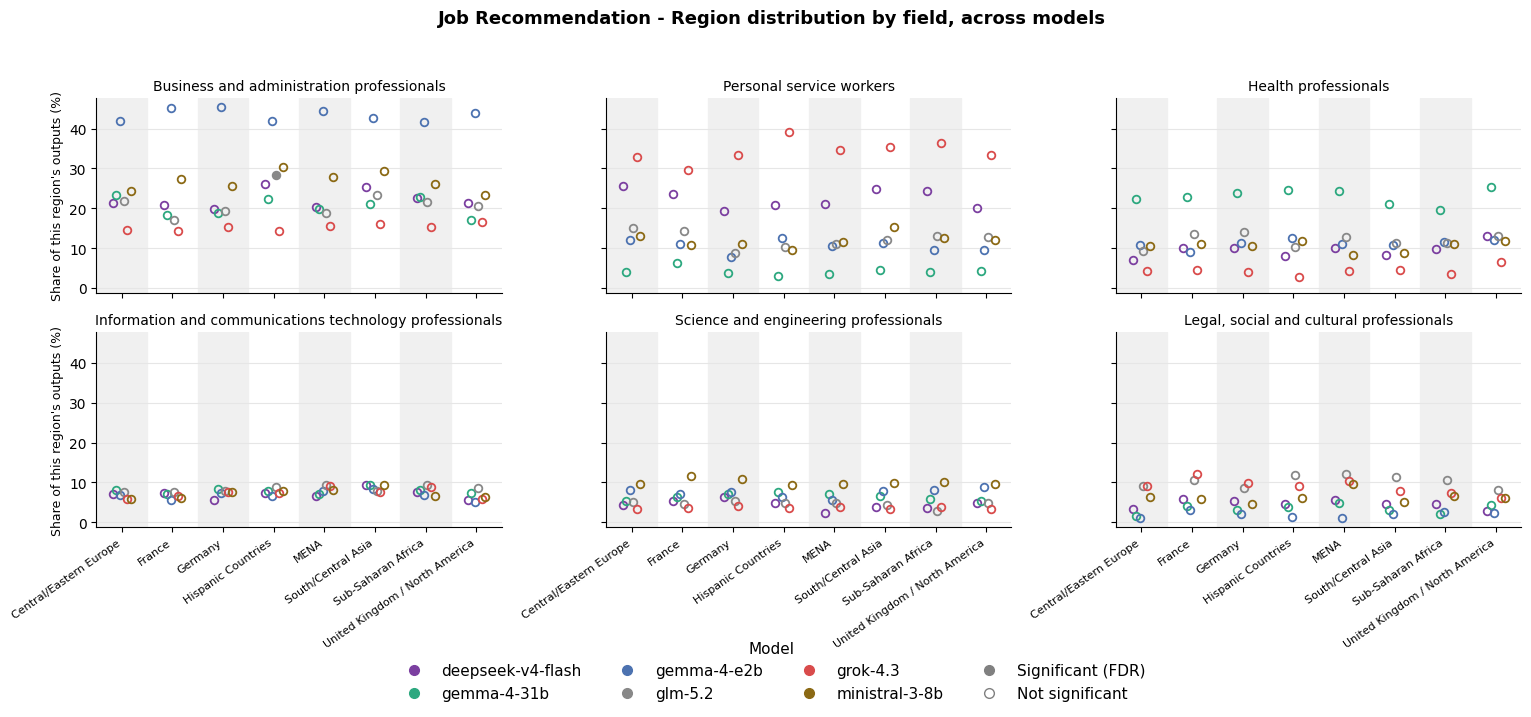

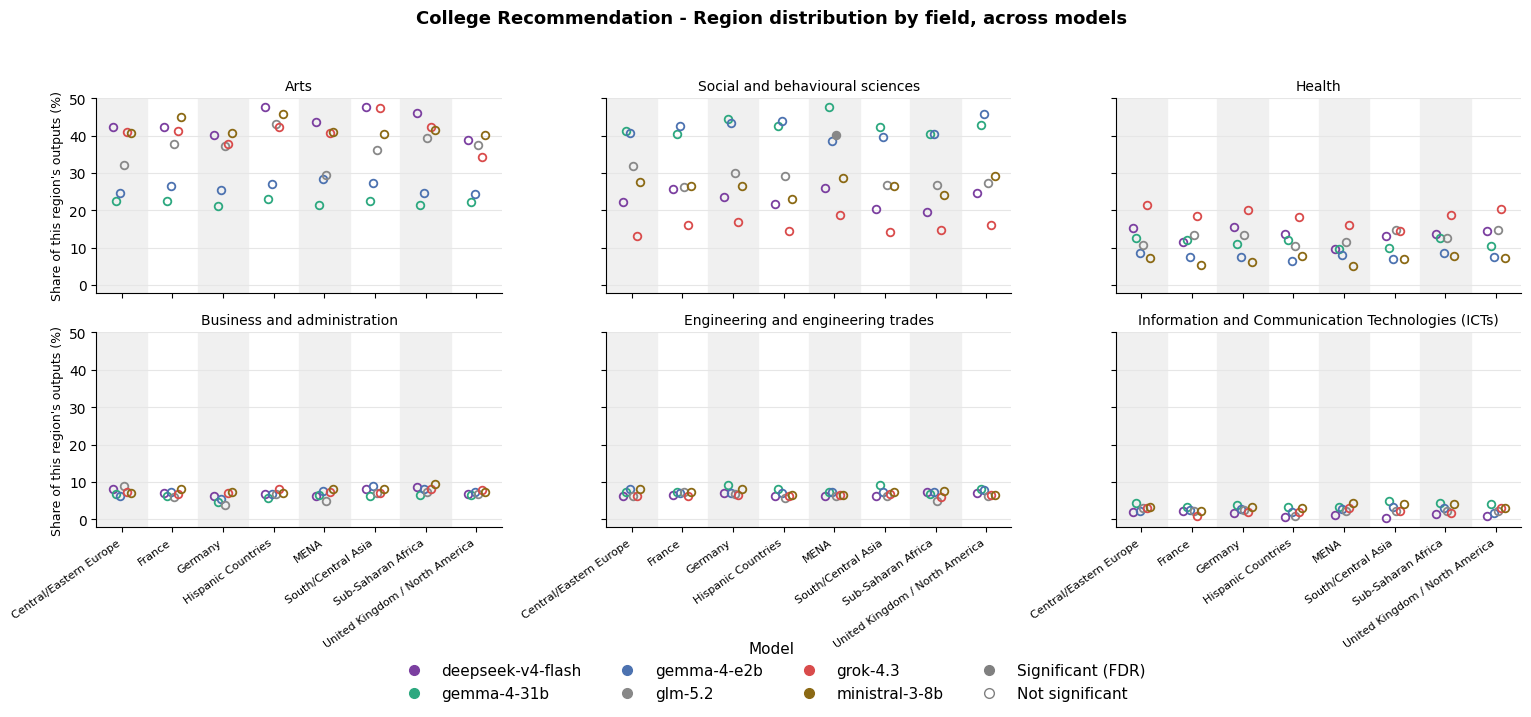

In [332]:
def region_smallmultiples_nosig(df: pd.DataFrame, question: str, n_cols=3):
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())

    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    top_cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )

    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(top_cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(top_cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["share_pct"], marker="o", linestyle="none",
                        markersize=5.5,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.3, zorder=3)

        ax.set_title(cat, fontsize=10)
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=35, ha="right", fontsize=8)
        ax.grid(axis="y", color="0.9", zorder=1)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("Share of this region's outputs (%)", fontsize=9)

    for ax in axes[len(top_cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Region distribution by field, across models",
                 fontsize=13, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    fig.legend(handles=handles, title="Model", loc="lower center",
               bbox_to_anchor=(0.5, 0.0), ncol=(len(handles) + 1) // 2,
               fontsize=11, title_fontsize=11, frameon=False)

    fig.tight_layout(rect=[0, 0.07, 0.99, 0.95])
    plt.show()


for q in sorted(df["question_key"].unique()):
    region_smallmultiples_nosig(df, q)


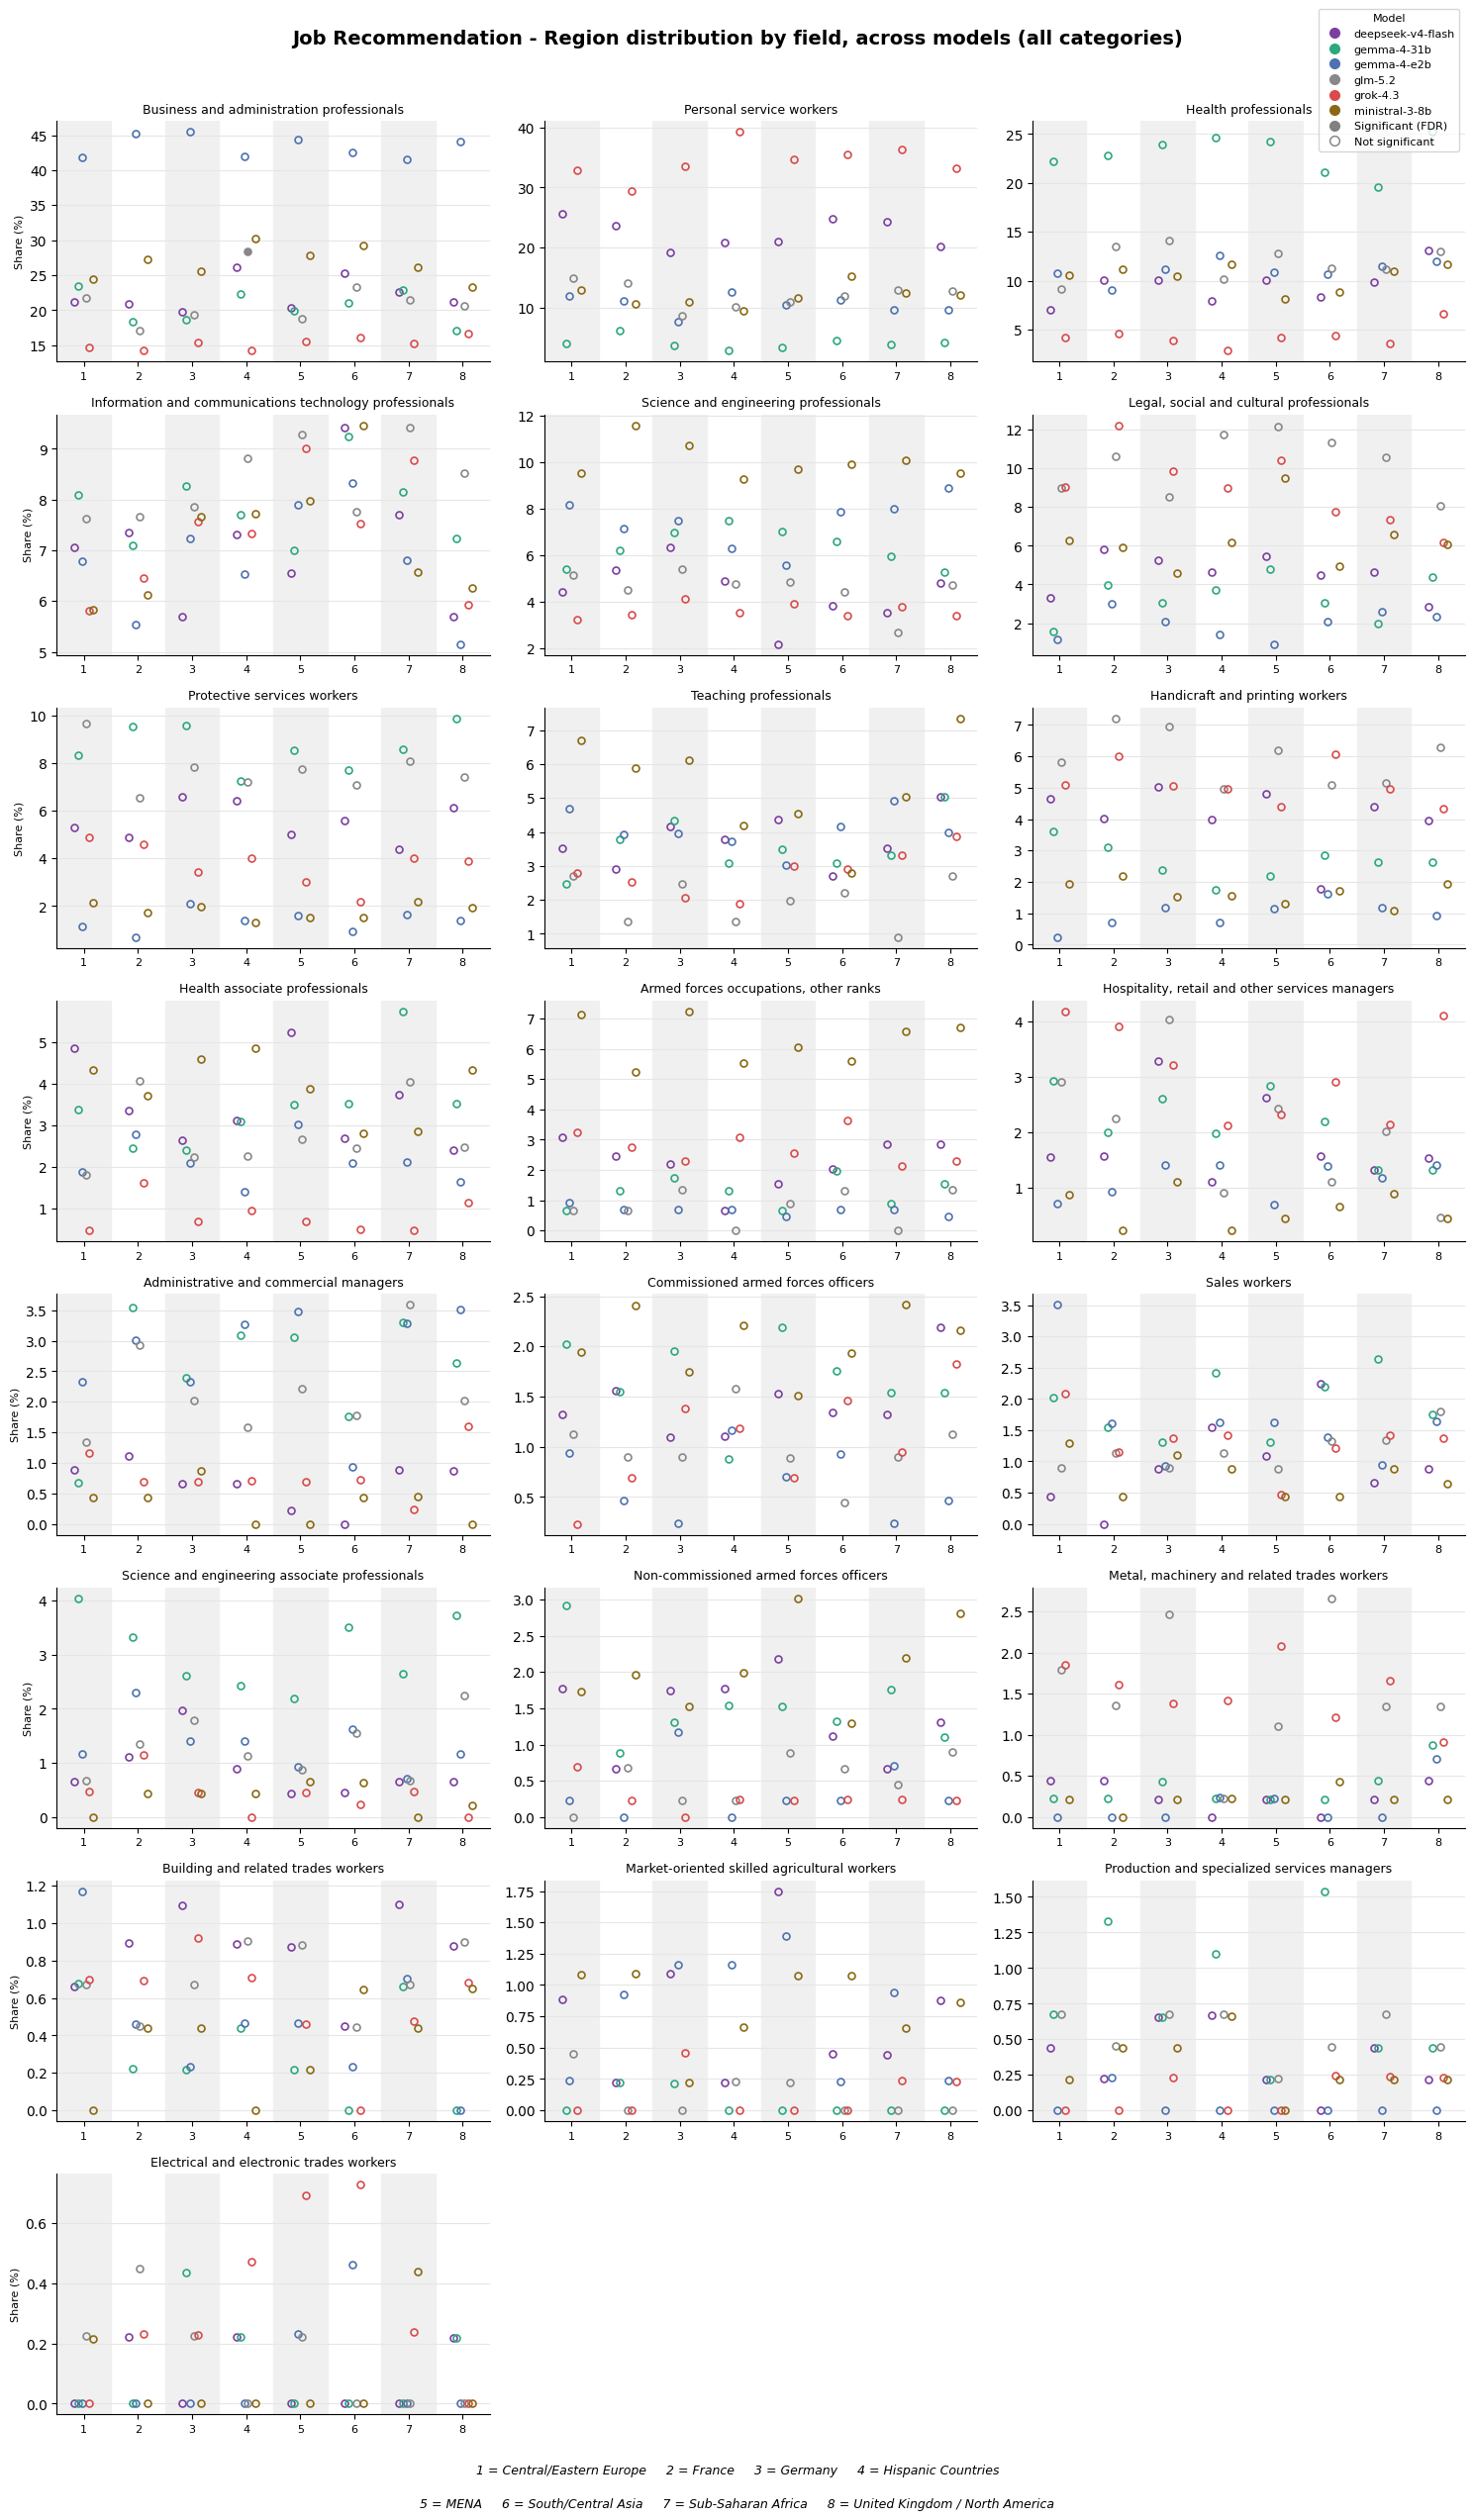

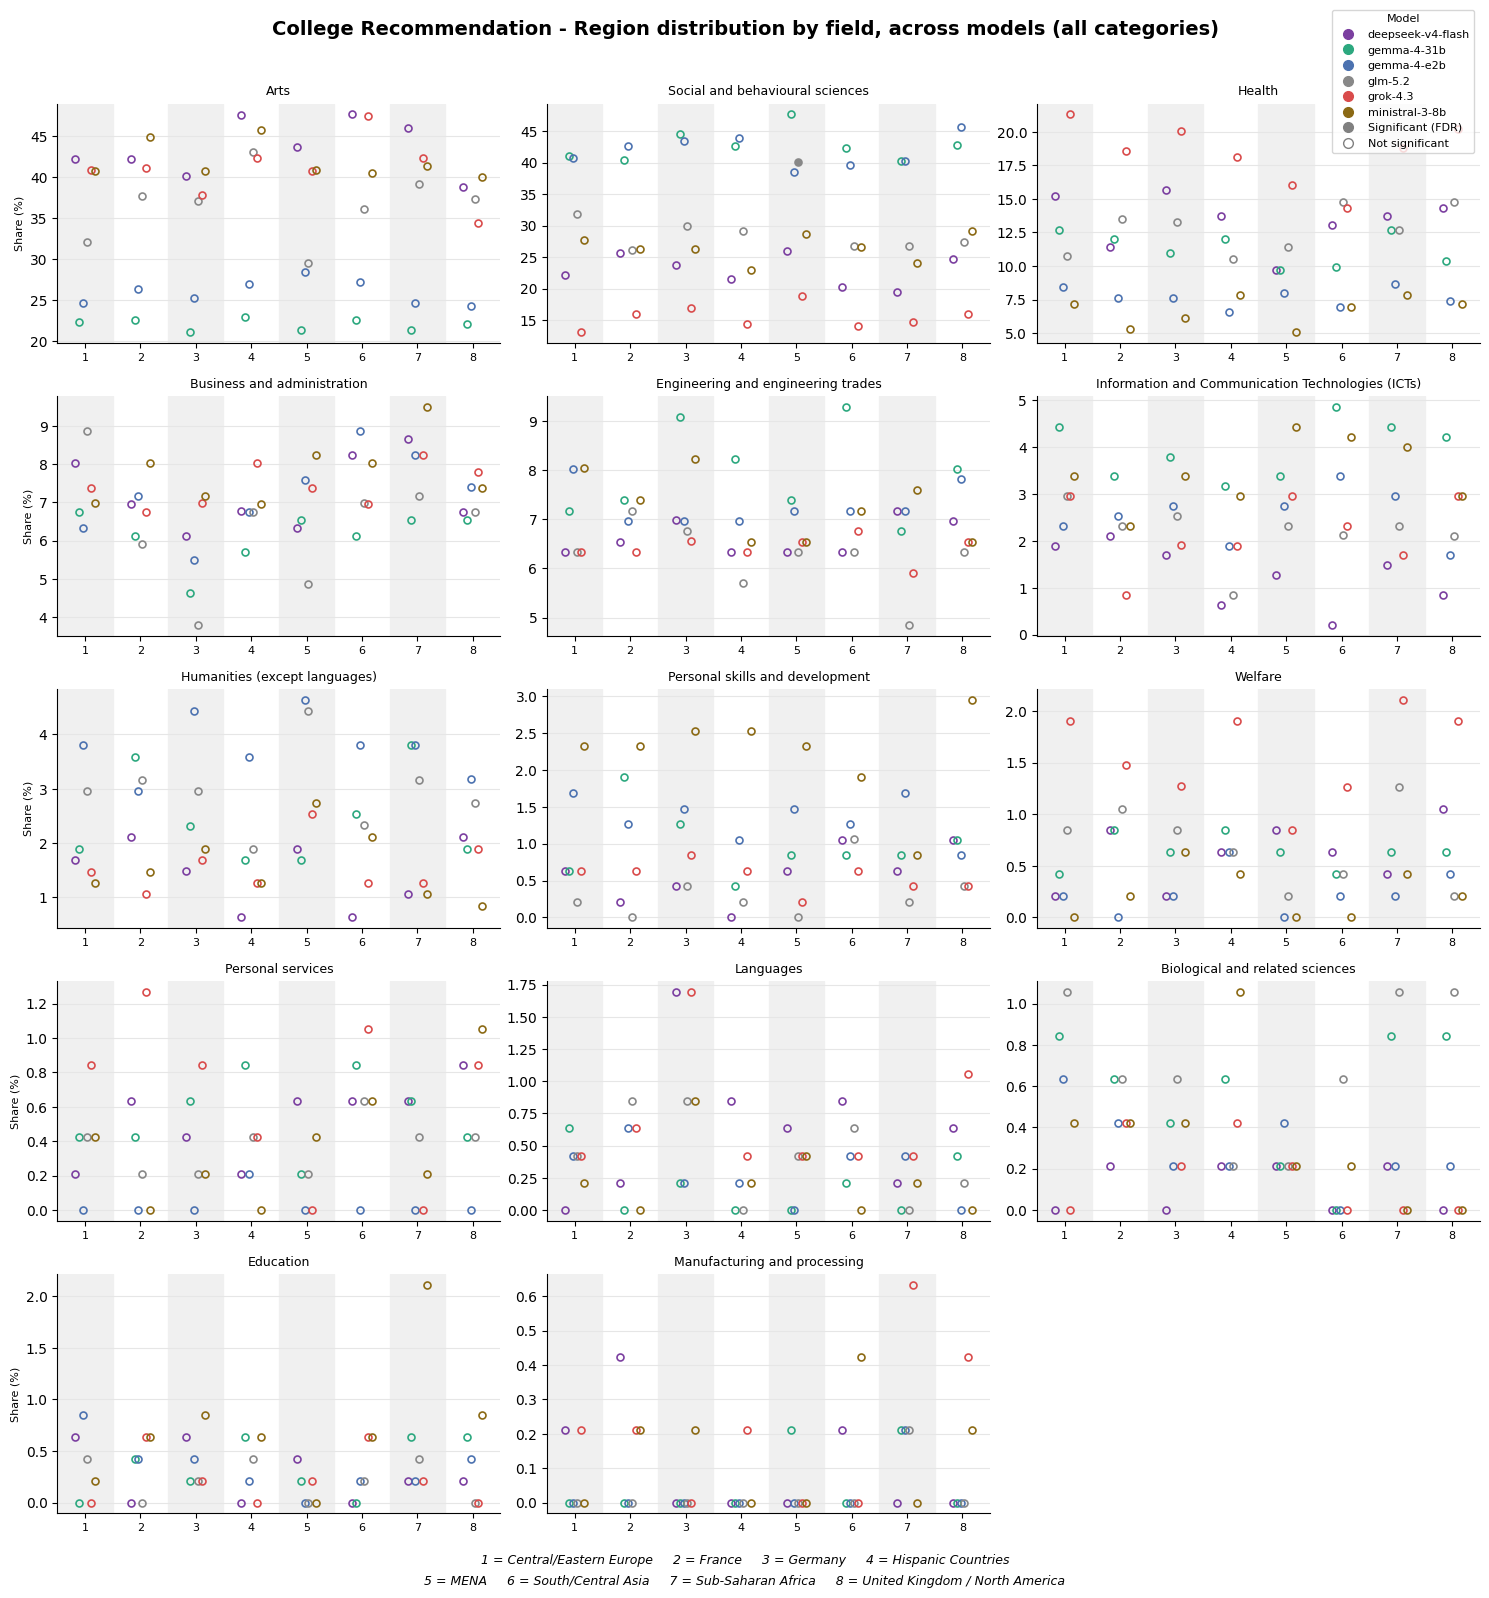

In [333]:
def region_smallmultiples_allcats(df: pd.DataFrame, question: str, n_cols=3):
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())
    region_num = {r: i + 1 for i, r in enumerate(regions)}

    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).index.tolist()
    )

    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5.0 * n_cols, 3.2 * n_rows),
                             sharex=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["share_pct"], marker="o", linestyle="none",
                        markersize=5,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.2, zorder=3)
            ax.set_title(cat, fontsize=9)

        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels([str(region_num[r]) for r in regions], fontsize=8)
        ax.tick_params(labelbottom=True)
        ax.grid(axis="y", color="0.9", zorder=1)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("Share (%)", fontsize=8)

    for ax in axes[len(cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Region distribution by field, across models (all categories)",
                 fontsize=14, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    fig.legend(handles=handles, title="Model", loc="upper right",
               bbox_to_anchor=(0.99, 0.99), fontsize=8, title_fontsize=8)

    items = [f"{n} = {r}" for r, n in region_num.items()]
    half = len(items) // 2 + len(items) % 2
    fig.text(0.5, 0.015, "     ".join(items[:half]), ha="center", fontsize=9, style="italic")
    fig.text(0.5, 0.002, "     ".join(items[half:]), ha="center", fontsize=9, style="italic")

    fig.tight_layout(rect=[0, 0.025, 1, 0.97])
    plt.show()


for q in sorted(df["question_key"].unique()):
    region_smallmultiples_allcats(df, q)


#### Findings table — significant region categories (Q2)

Significant region-skewed college-major categories (FDR-adjusted), strongest finding per
category. Reuses the `findings_table` helper defined in the Gender section.

In [ ]:
print("Significant region findings — Q2 (college major recommendations)")
display(findings_table("q2_region", top_n=12, significant_only=True))

## Real Conversation Histories (WildChat)

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT = _repo_root()


def _find_csv(name: str) -> Path:
    """Locate a results CSV anywhere in the repo (works on Mac and Windows checkouts)."""
    hits = list(REPO_ROOT.rglob(name))
    assert hits, f"Not found anywhere under {REPO_ROOT}: {name}"
    return hits[0]


# Same output location as experiments/eval_real_conversations_full.ipynb
WC_OUTPUT_DIR = REPO_ROOT / "experiments" / "behavioral_audit" / "results_wildchat"
WC_FIGURES_DIR = WC_OUTPUT_DIR / "figures" / "wildchat001-eval"

_EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "behavioral_audit"
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}
Q2_BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

### Gender Confusion Matrix (Direct Probing on WildChat)

In [ ]:
# Direct probing judgments (gender) on real WildChat conversation histories
DP_EXPERIMENT = "direct-probing-wildchat-wildchat001"
DP_FIGURES = WC_FIGURES_DIR / "direct-probing"
DP_FIGURES.mkdir(parents=True, exist_ok=True)

dp_raw = pd.read_csv(_find_csv(f"{DP_EXPERIMENT}-stage2.judgments.csv"))
dp = dp_raw[dp_raw["status"] == "success"].copy().reset_index(drop=True)
judge_aliases = sorted(dp["judge_alias"].unique().tolist())
dp = dp[dp["judge_alias"] == judge_aliases[0]].reset_index(drop=True)

_meta = dp["metadata"].apply(lambda s: json.loads(s) if isinstance(s, str) and s.strip() else {})
dp["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
dp["predicted_gender"] = dp["final_class"]
dp["gender_correct"] = dp["predicted_gender"] == dp["true_gender"]

print(f"Overall accuracy: {dp['gender_correct'].mean():.1%}  (n={len(dp)})")
print("\nGender confusion matrix:")
print(pd.crosstab(dp["true_gender"], dp["predicted_gender"], margins=True))

Overall accuracy: 100.0%  (n=50)

Gender confusion matrix:
predicted_gender  Female  Male  All
true_gender                        
Female                25     0   25
Male                   0    25   25
All                   25    25   50


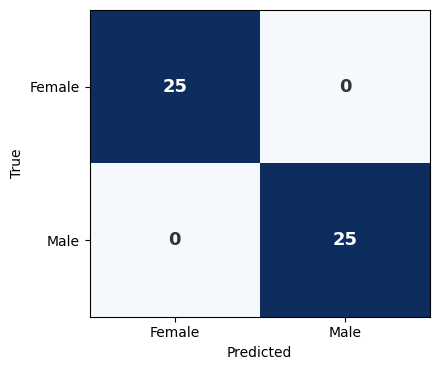

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

gender_ct = pd.crosstab(dp["true_gender"], dp["predicted_gender"])
paper_blues = LinearSegmentedColormap.from_list("paper_blues", ["#f5f8fc", "#1f77b4", "#0d2d5e"])

fig, ax = plt.subplots(figsize=(4.5, 3.8))
ax.imshow(gender_ct.values, cmap=paper_blues, aspect="auto", vmin=0)
ax.set_xticks(range(len(gender_ct.columns)))
ax.set_xticklabels(gender_ct.columns)
ax.set_yticks(range(len(gender_ct.index)))
ax.set_yticklabels(gender_ct.index)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
maxv = gender_ct.values.max()
for i in range(len(gender_ct.index)):
    for j in range(len(gender_ct.columns)):
        v = gender_ct.values[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=13, fontweight="bold",
                color="white" if v > maxv * 0.5 else "#333333")
plt.tight_layout()
plt.show()


### Gender Gap: Real (WildChat) vs. Synthetic Histories

In [ ]:
def _load_run(run_tag, q_tag, group_col):
    csv_path = _find_csv(f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv")
    df_raw = pd.read_csv(csv_path)
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["run"] = run_tag
    df[group_col] = df["final_class"].map(
        Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS
    )
    return df


cmp_q1 = pd.concat([
    _load_run("wildchat001", "q1", "major_group"),
    _load_run("full001", "q1", "major_group"),
], ignore_index=True)
cmp_q2 = pd.concat([
    _load_run("wildchat001", "q2", "broad_field"),
    _load_run("full001", "q2", "broad_field"),
], ignore_index=True)


RUN_PAPER_COLORS = {"wildchat001": "#d94b4b", "full001": "#377eb8"}

# Same output location as experiments/eval_real_conversations_full.ipynb
SEC45_DIR = WC_FIGURES_DIR / "section-4-5"
SEC45_DIR.mkdir(parents=True, exist_ok=True)

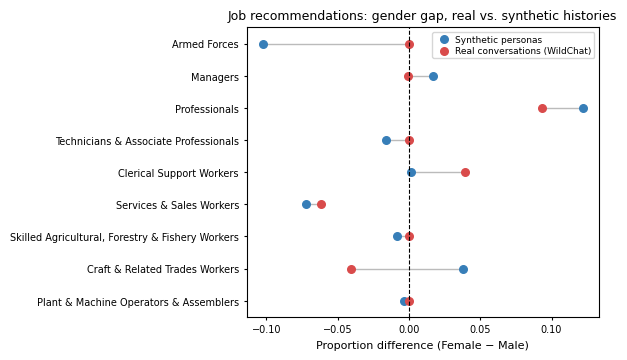

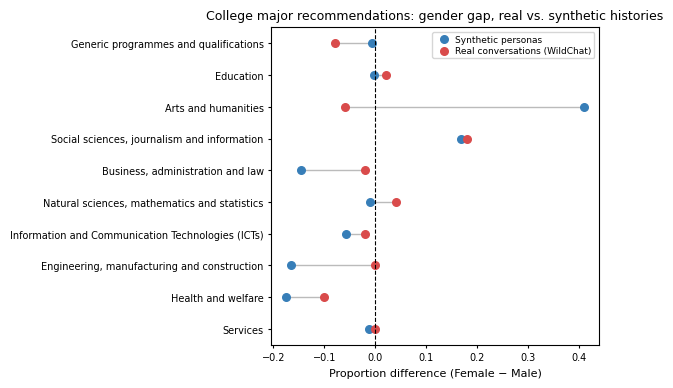

In [ ]:
def plot_gender_gap_comparison(cmp_df, group_col, q_label, min_total=5):
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    keep = [lvl for lvl in levels if (cmp_df[group_col] == lvl).sum() >= min_total]

    diffs = {}
    for run in ["wildchat001", "full001"]:
        sub = cmp_df[cmp_df["run"] == run]
        f = sub[sub["true_gender"] == "Female"]
        m = sub[sub["true_gender"] == "Male"]
        diffs[run] = [(f[group_col] == lvl).mean() - (m[group_col] == lvl).mean() for lvl in keep]

    y = np.arange(len(keep))
    fig, ax = plt.subplots(figsize=(6, 0.28 * len(keep) + 1.0))
    for i in range(len(keep)):
        ax.plot([diffs["full001"][i], diffs["wildchat001"][i]], [y[i], y[i]],
                color="#bbbbbb", lw=1, zorder=1)
    ax.scatter(diffs["full001"], y, color=RUN_PAPER_COLORS["full001"], s=30,
               label="Synthetic personas", zorder=2)
    ax.scatter(diffs["wildchat001"], y, color=RUN_PAPER_COLORS["wildchat001"], s=30,
               label="Real conversations (WildChat)", zorder=2)
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels(keep, fontsize=7)
    ax.set_ylim(len(keep) - 0.5, -0.5)
    ax.margins(x=0.05)
    ax.tick_params(axis="both", labelsize=7, length=2)
    ax.set_xlabel("Proportion difference (Female − Male)", fontsize=8)
    ax.set_title(f"{q_label}: gender gap, real vs. synthetic histories", fontsize=9)
    ax.legend(fontsize=6.5, handletextpad=0.3, borderpad=0.3, labelspacing=0.3)
    plt.tight_layout(pad=0.4)
    plt.show()
    plt.close(fig)


plot_gender_gap_comparison(cmp_q1, "major_group", "Job recommendations")
plot_gender_gap_comparison(cmp_q2, "broad_field", "College major recommendations")
